# estudo do nnúmero de intervalos

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('utils\painxai.mplstyle')

In [2]:
def _bin_data(probs: np.ndarray,
              labels: np.ndarray,
              n_bins: int = 10,
              mode: str = 'uniform') -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    probs = np.asarray(probs, dtype=float)
    labels = np.asarray(labels, dtype=float)

    if mode == 'uniform':
        bins = np.linspace(0.0, 1.0, n_bins + 1)
    elif mode == 'quantile':
        quantiles = np.linspace(0, 1, n_bins + 1)
        bins = np.percentile(probs, quantiles * 100)
    else:
        raise ValueError(f"Unknown binning mode: {mode}")

    binids = np.searchsorted(bins[1:-1], probs)
    unique_bins = np.unique(binids)

    std = []
    for unique_bin in unique_bins:
        test = probs[binids == unique_bin]
        std.append(np.std(test, ddof=0))  # population std -> never NaN for len==1

    bin_sums = np.bincount(binids, weights=probs, minlength=len(bins))
    bin_true = np.bincount(binids, weights=labels, minlength=len(bins))
    bin_total = np.bincount(binids, minlength=len(bins))

    nonzero = bin_total != 0
    prob_true = bin_true[nonzero] / bin_total[nonzero]
    prob_pred = bin_sums[nonzero] / bin_total[nonzero]

    return prob_true, prob_pred, bin_total[nonzero], float(np.mean(std))


def ECE(probs: np.ndarray,
        labels: np.ndarray,
        n_bins: int = 10,
        mode: str = 'uniform') -> tuple[float, float]:
    prob_true, prob_pred, bin_total, stds = _bin_data(probs, labels, n_bins, mode)
    P = bin_total / np.sum(bin_total)
    ece = np.sum(np.abs(prob_true - prob_pred) * P)
    return ece, stds


In [3]:
mode = 'uniform'
N_BINS = 10

In [4]:
import pickle
import pandas as pd

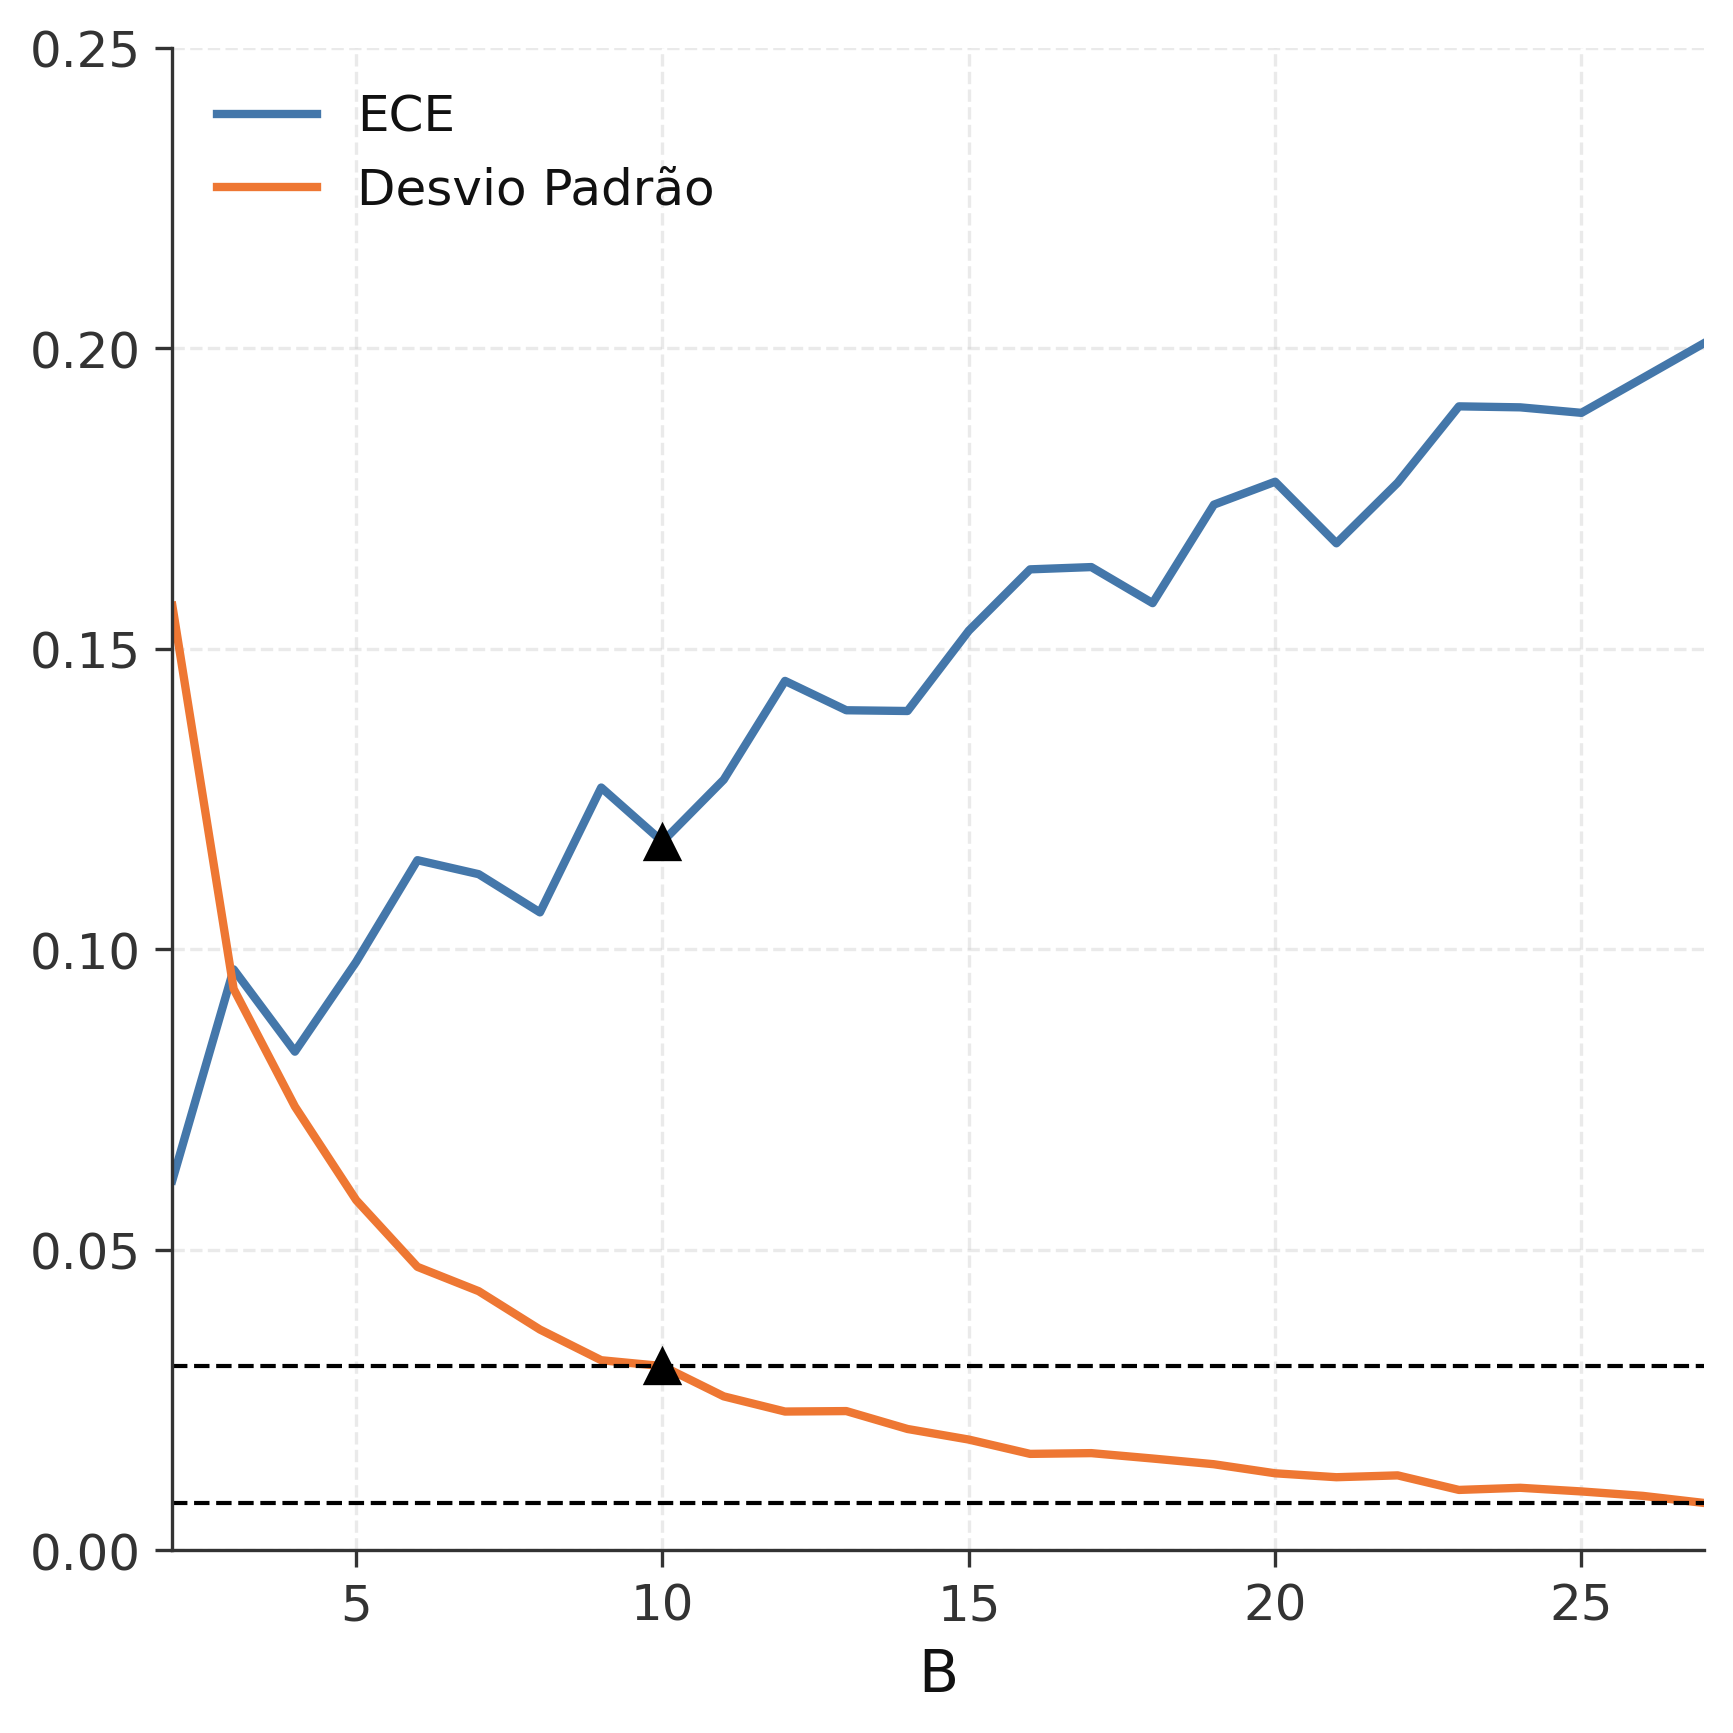

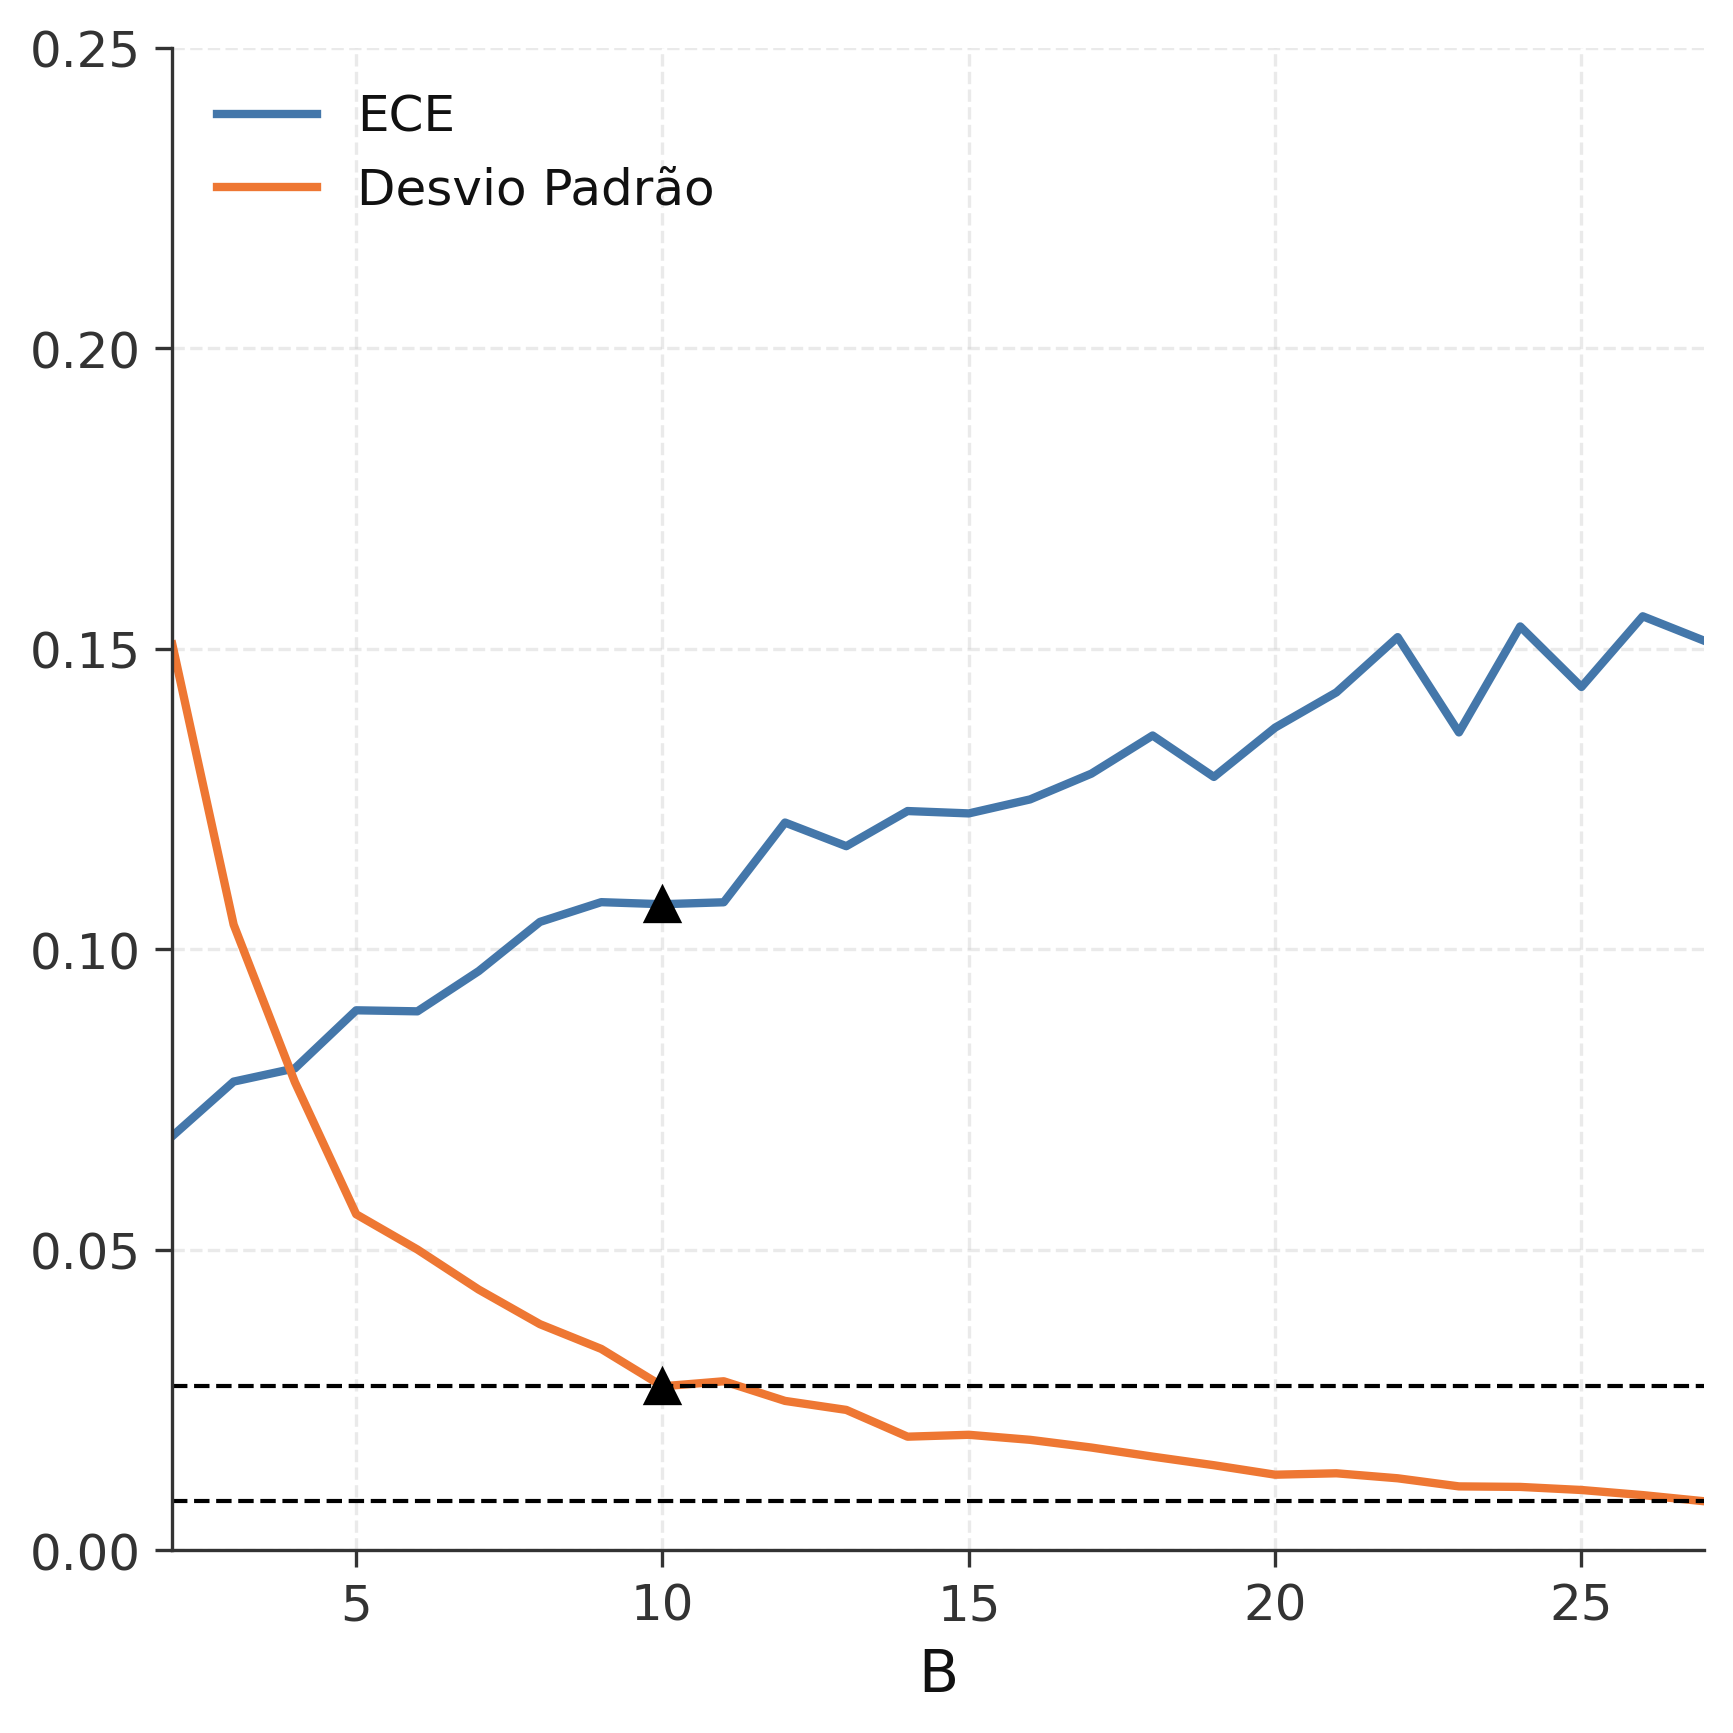

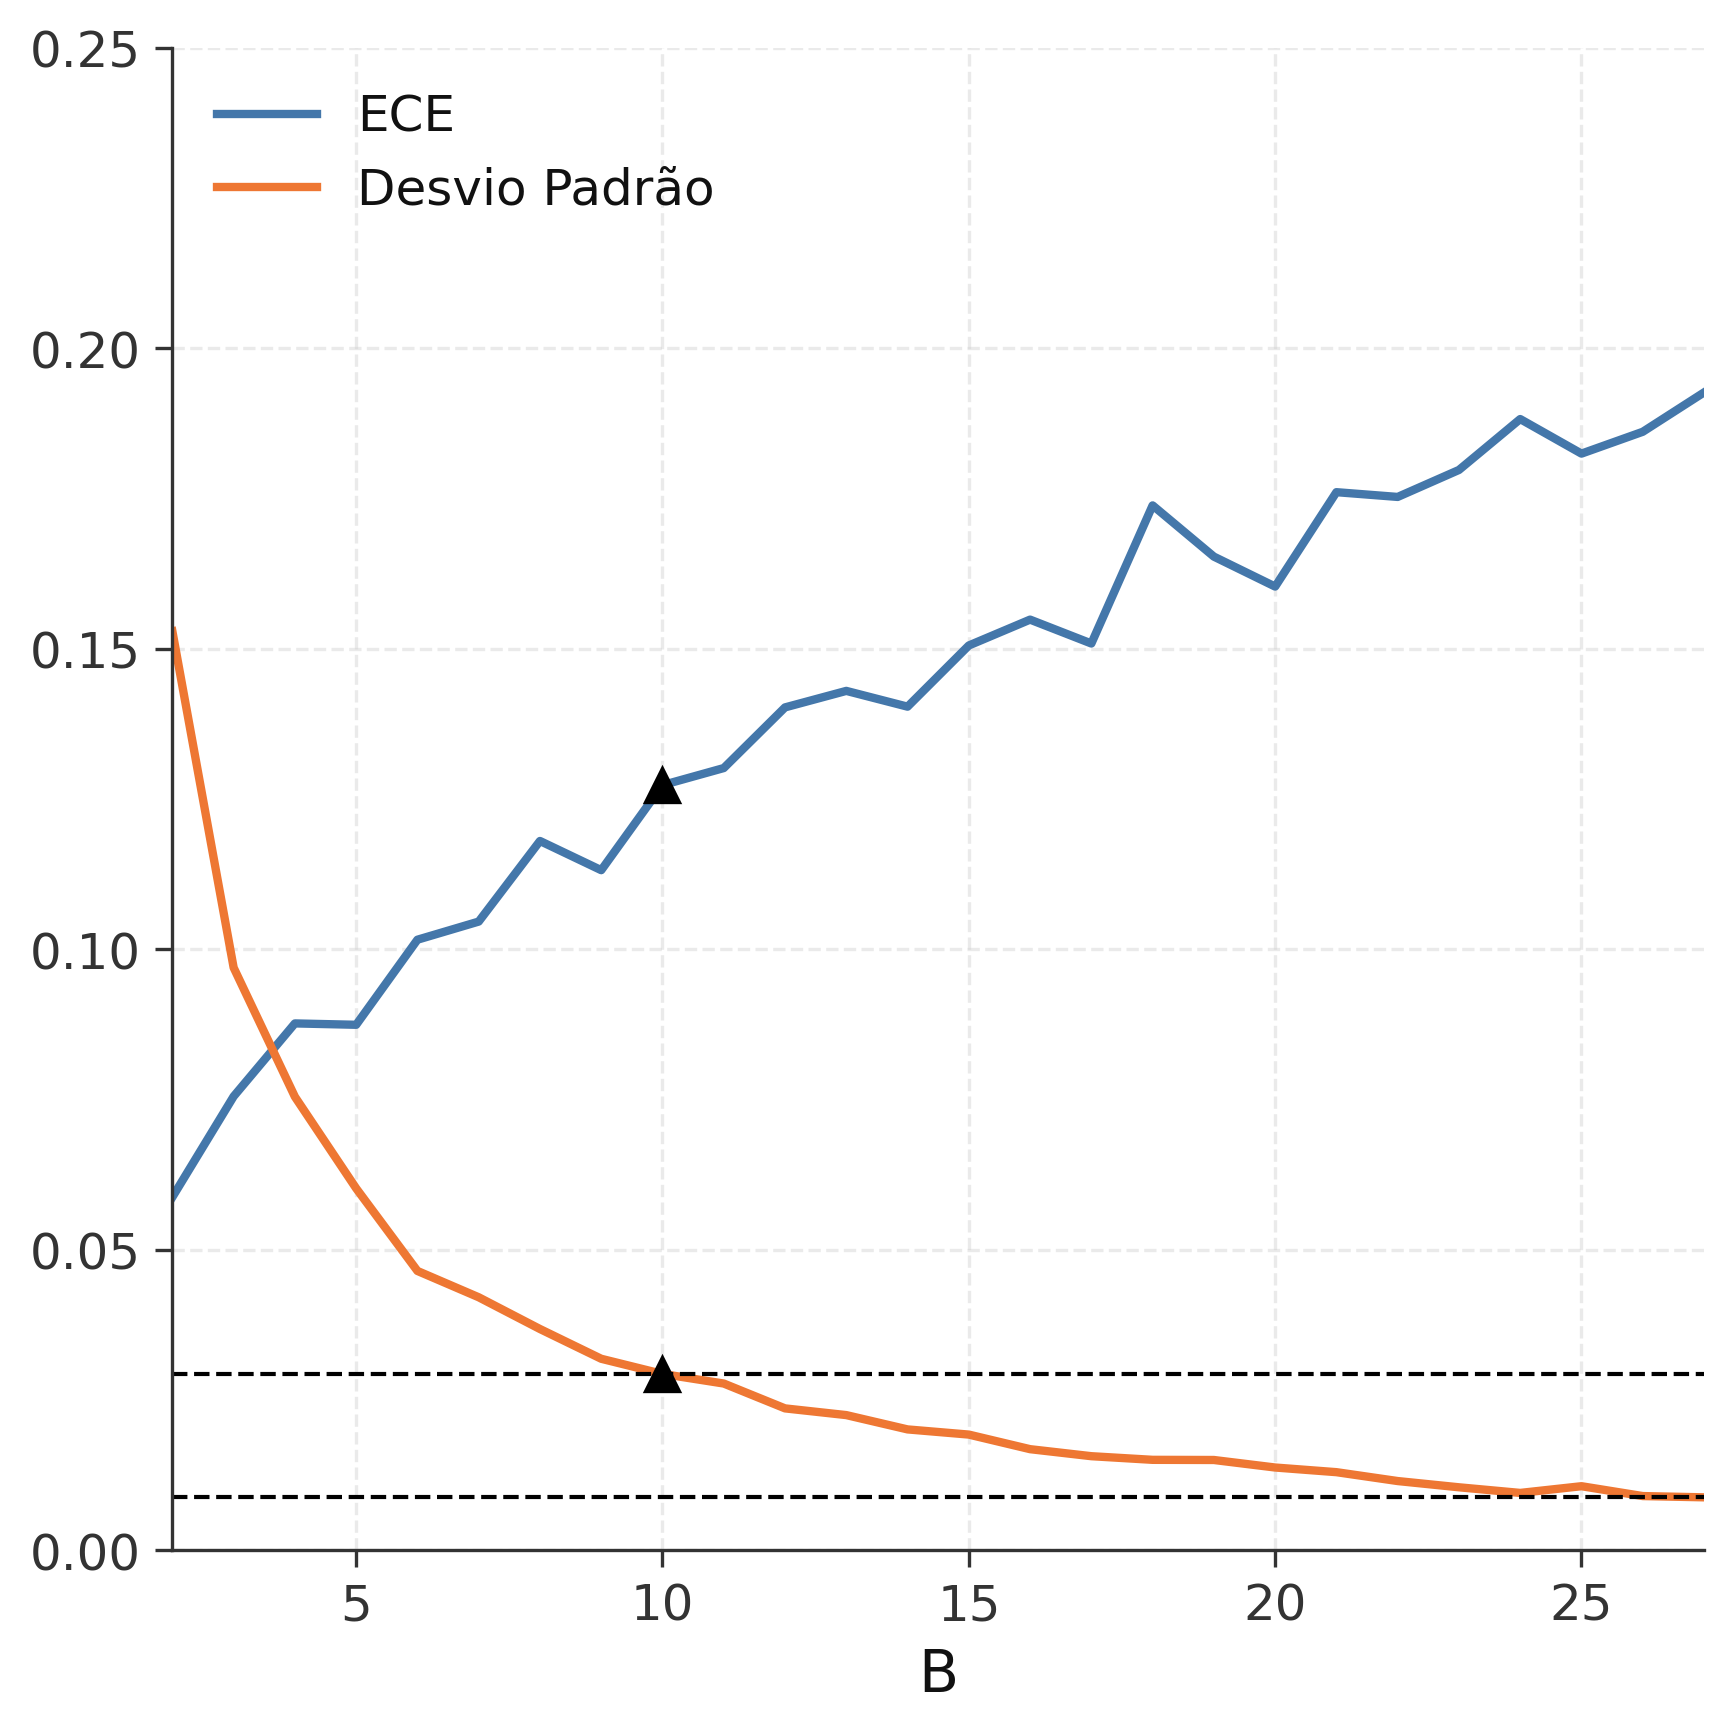

In [6]:
total = 28
step = 1

for i, model in enumerate(['NCNN', 'VGGFace', 'ViT_B_32']):

    plt.figure(figsize=(6,6))

    with open(f'experiments\\{model}\\results.pkl', 'rb') as f:
        results = pd.DataFrame(pickle.load(f))

    ece_means = []
    std_means = []

    for n_bins in range(2,total,step):

        ece_list = []
        std_bins = []

        for fold in results['fold'].unique():

            ece, std = ECE(results[results['fold']==fold]['probs'], results[results['fold']==fold]['labels'], n_bins=n_bins, mode='quantile')
            ece_list.append(ece)
            std_bins.append(std)

        ece_means.append(np.array(ece_list).mean())
        std_means.append(np.array(std_bins).mean())

        #print(f"{ece_list.mean():.4f} \t {std_bins.mean():.4f}".replace('.',','))

    plt.plot(np.arange(2,total,step), ece_means)
    plt.plot(np.arange(2,total,step), std_means)

    plt.plot(10, ece_means[8], 'k^', markersize=8)
    plt.plot(10, std_means[8], 'k^', markersize=8)

    plt.hlines(std_means[8], xmin=2, xmax=27, linestyle='--', colors='black', linewidth=1)
    plt.hlines(std_means[-1], xmin=2, xmax=27, linestyle='--', colors='black', linewidth=1)

    #model = 'VGG-Face' if model == "VGGNB" else model
    #model = 'N-CNN' if model == "NCNN" else model
    #model = 'ViT-B/32' if model == "ViT_B_32" else model
    #plt.title(model)

    plt.xlim([2,27])
    plt.ylim([0, 0.250])
    plt.legend(['ECE', 'Desvio Padrão'] ,loc='upper left')
    plt.xlabel("B")
    plt.savefig(f'k_intervalo_{model}.pdf', 
                    dpi=300, 
                    bbox_inches='tight')
    

# Curva de Calibração

### Falta de confiança

In [7]:
A = 18
B = -9

In [8]:
x = np.arange(0,1,0.01)
y = 1 / (1 + np.exp(-(A * x + B)))
x_points = np.arange(0,1,0.12)
y_points = 1 / (1 + np.exp(-(A * x_points + B)))

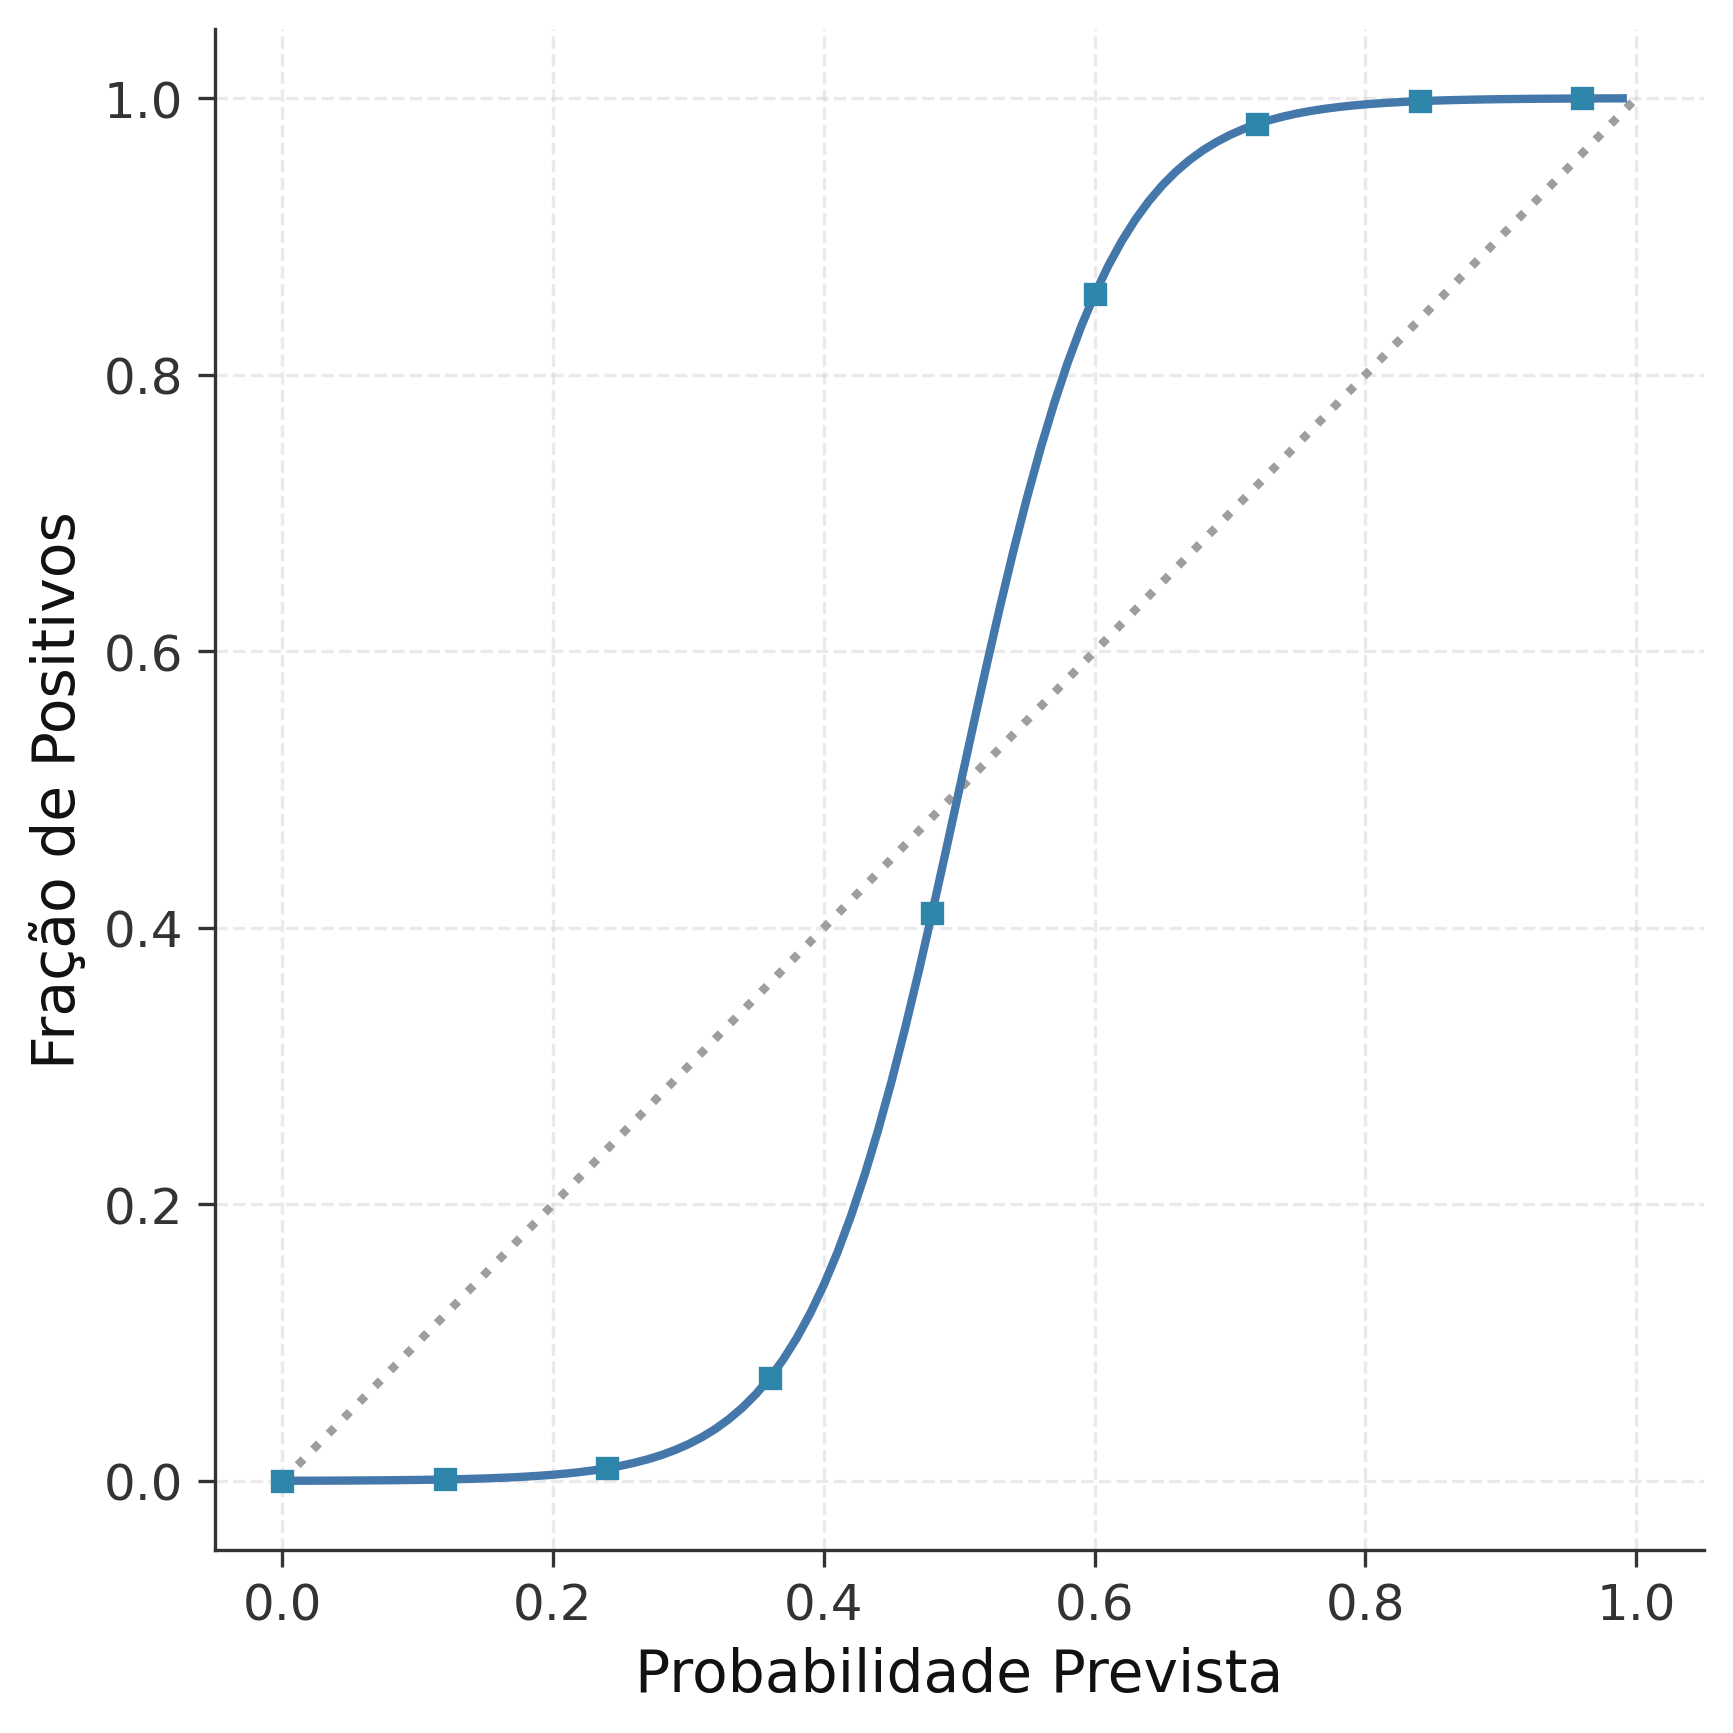

In [9]:
plt.figure(figsize=(6, 6))
plt.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), linestyle=":", color='#9e9e9e')
plt.plot(x,y)
plt.plot(x_points, y_points, 's', color='#2E86AB')

plt.xlabel('Probabilidade Prevista')
plt.ylabel('Fração de Positivos')
plt.savefig('undercofidence_example.pdf', dpi=300, bbox_inches='tight')


C:\Users\leona\AppData\Local\Temp\ipykernel_23224\3553570799.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('gradient_arrow_example.pdf', dpi=300, bbox_inches='tight')
C:\Users\leona\AppData\Local\Temp\ipykernel_23224\3553570799.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('gradient_arrow_example.pdf', dpi=300, bbox_inches='tight')
c:\Users\leona\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


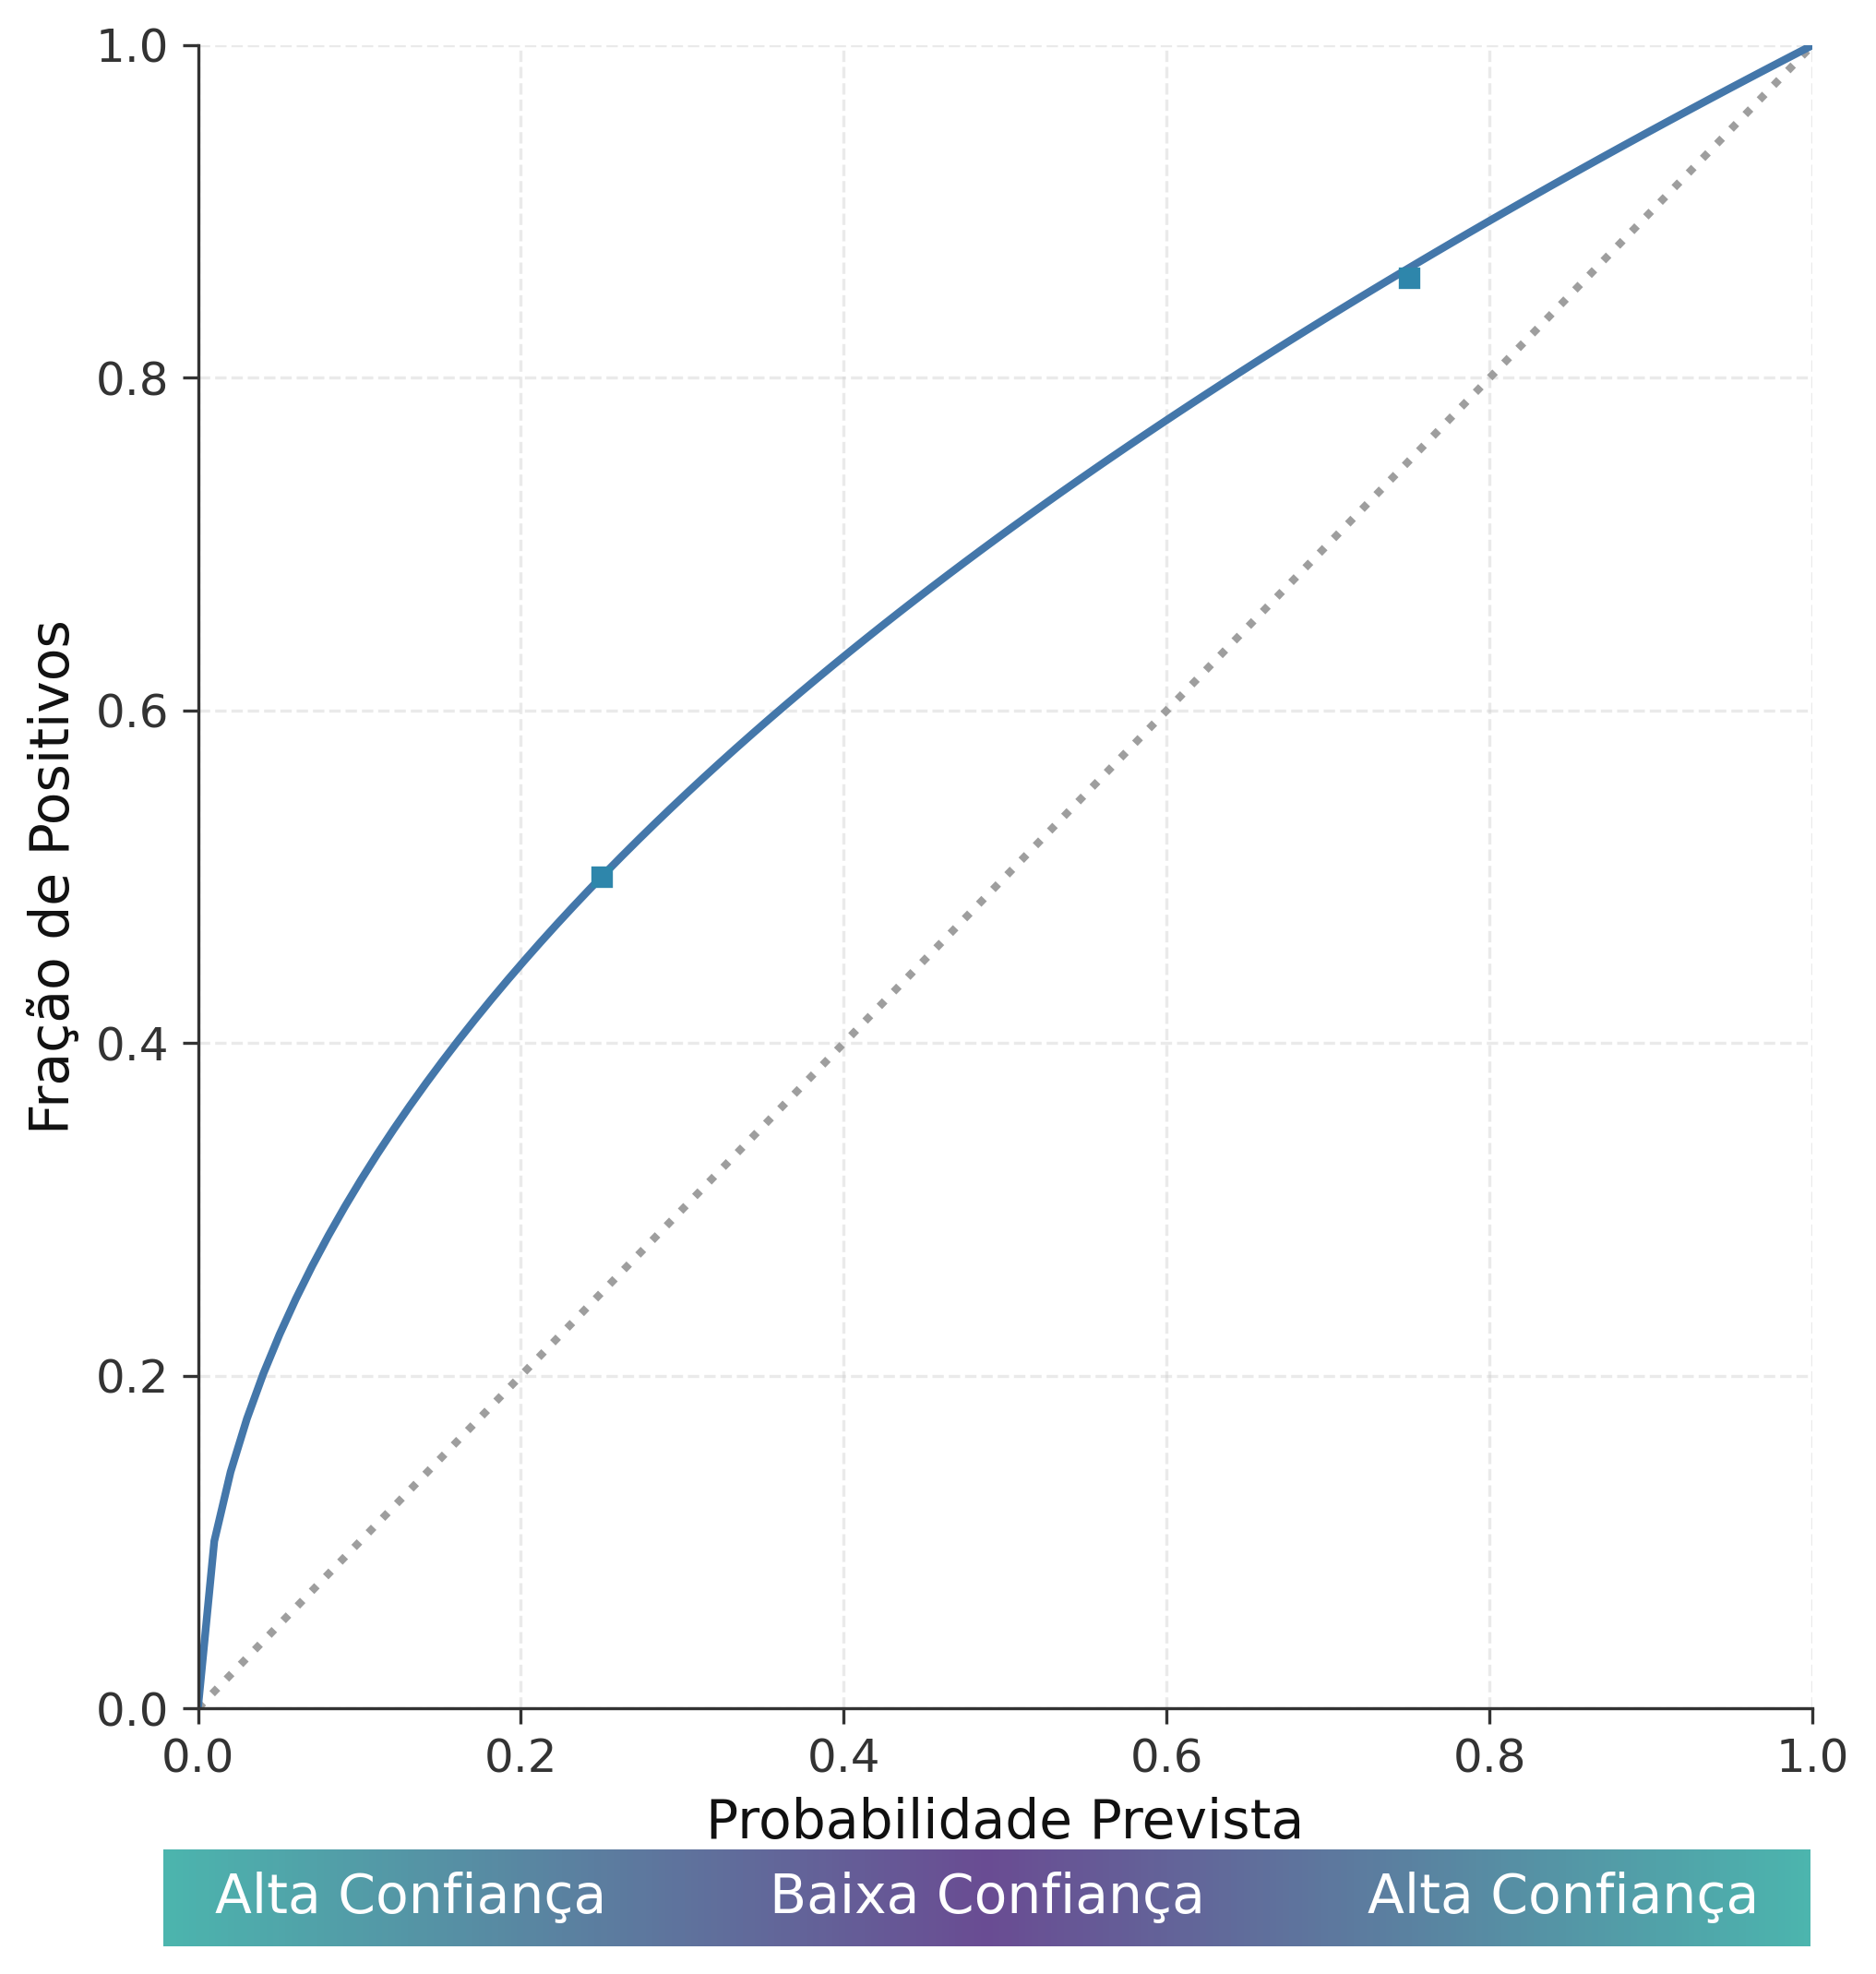

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

# --- 1. Main Plot Setup ---
# Use subplots for better control over the figure and axes
fig, ax = plt.subplots(figsize=(7, 7))

# Example data for a runnable example:
x = np.linspace(0, 1, 100)
y = np.sqrt(x)
x_points = [0.25, 0.75]
y_points = [0.5, 0.86]

# Plot your data
ax.plot(np.arange(0, 1.1, 0.1), np.arange(0, 1.1, 0.1), linestyle=":", color='#9e9e9e')
ax.plot(x, y)
ax.plot(x_points, y_points, 's', color='#2E86AB')

# Set labels and limits for the main plot
ax.set_xlabel('Probabilidade Prevista')
ax.set_ylabel('Fração de Positivos')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Adjust main plot position to make space at the bottom
fig.subplots_adjust(bottom=0.25)


# --- 2. Gradient Arrow ---
# Create a new axes for the gradient arrow at the bottom of the figure
# The list is [left, bottom, width, height] in figure coordinates
ax_gradient = fig.add_axes([0.1, -0.02, 0.85, 0.05])

# Define a "V" shaped colormap: blue -> light gray -> blue
high_conf_color = '#4CB5AE'  # A strong blue for high confidence
low_conf_color = '#6A4C93'   # A light gray for low confidence
colors = [high_conf_color, low_conf_color, high_conf_color]
v_cmap = mcolors.LinearSegmentedColormap.from_list('custom_v_map', colors)

# Create the data for the gradient image
gradient_data = np.linspace(0, 1, 256)
gradient_data = np.vstack((gradient_data, gradient_data)) # Make it 2D for imshow

# Display the gradient on the new axes
ax_gradient.imshow(gradient_data, aspect='auto', cmap=v_cmap)


# Add text labels on top of the gradient bar
ax_gradient.text(0.5, 0.5, 'Baixa Confiança', color='white', ha='center', va='center', transform=ax_gradient.transAxes)
ax_gradient.text(0.15, 0.5, 'Alta Confiança', color='white', ha='center', va='center', transform=ax_gradient.transAxes)
ax_gradient.text(0.85, 0.5, 'Alta Confiança', color='white', ha='center', va='center', transform=ax_gradient.transAxes)

# Hide the ticks and spines of the gradient's axes
ax_gradient.set_axis_off()

# Save the figure
plt.savefig('gradient_arrow_example.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [11]:
x = np.arange(0,1,0.01)
y = -0.7856*np.power(x,2) + 1.7658*x + 0.0429

x_points = np.arange(0,1,0.12)
y_points = -0.7856*np.power(x_points,2) + 1.7658*x_points + 0.0429

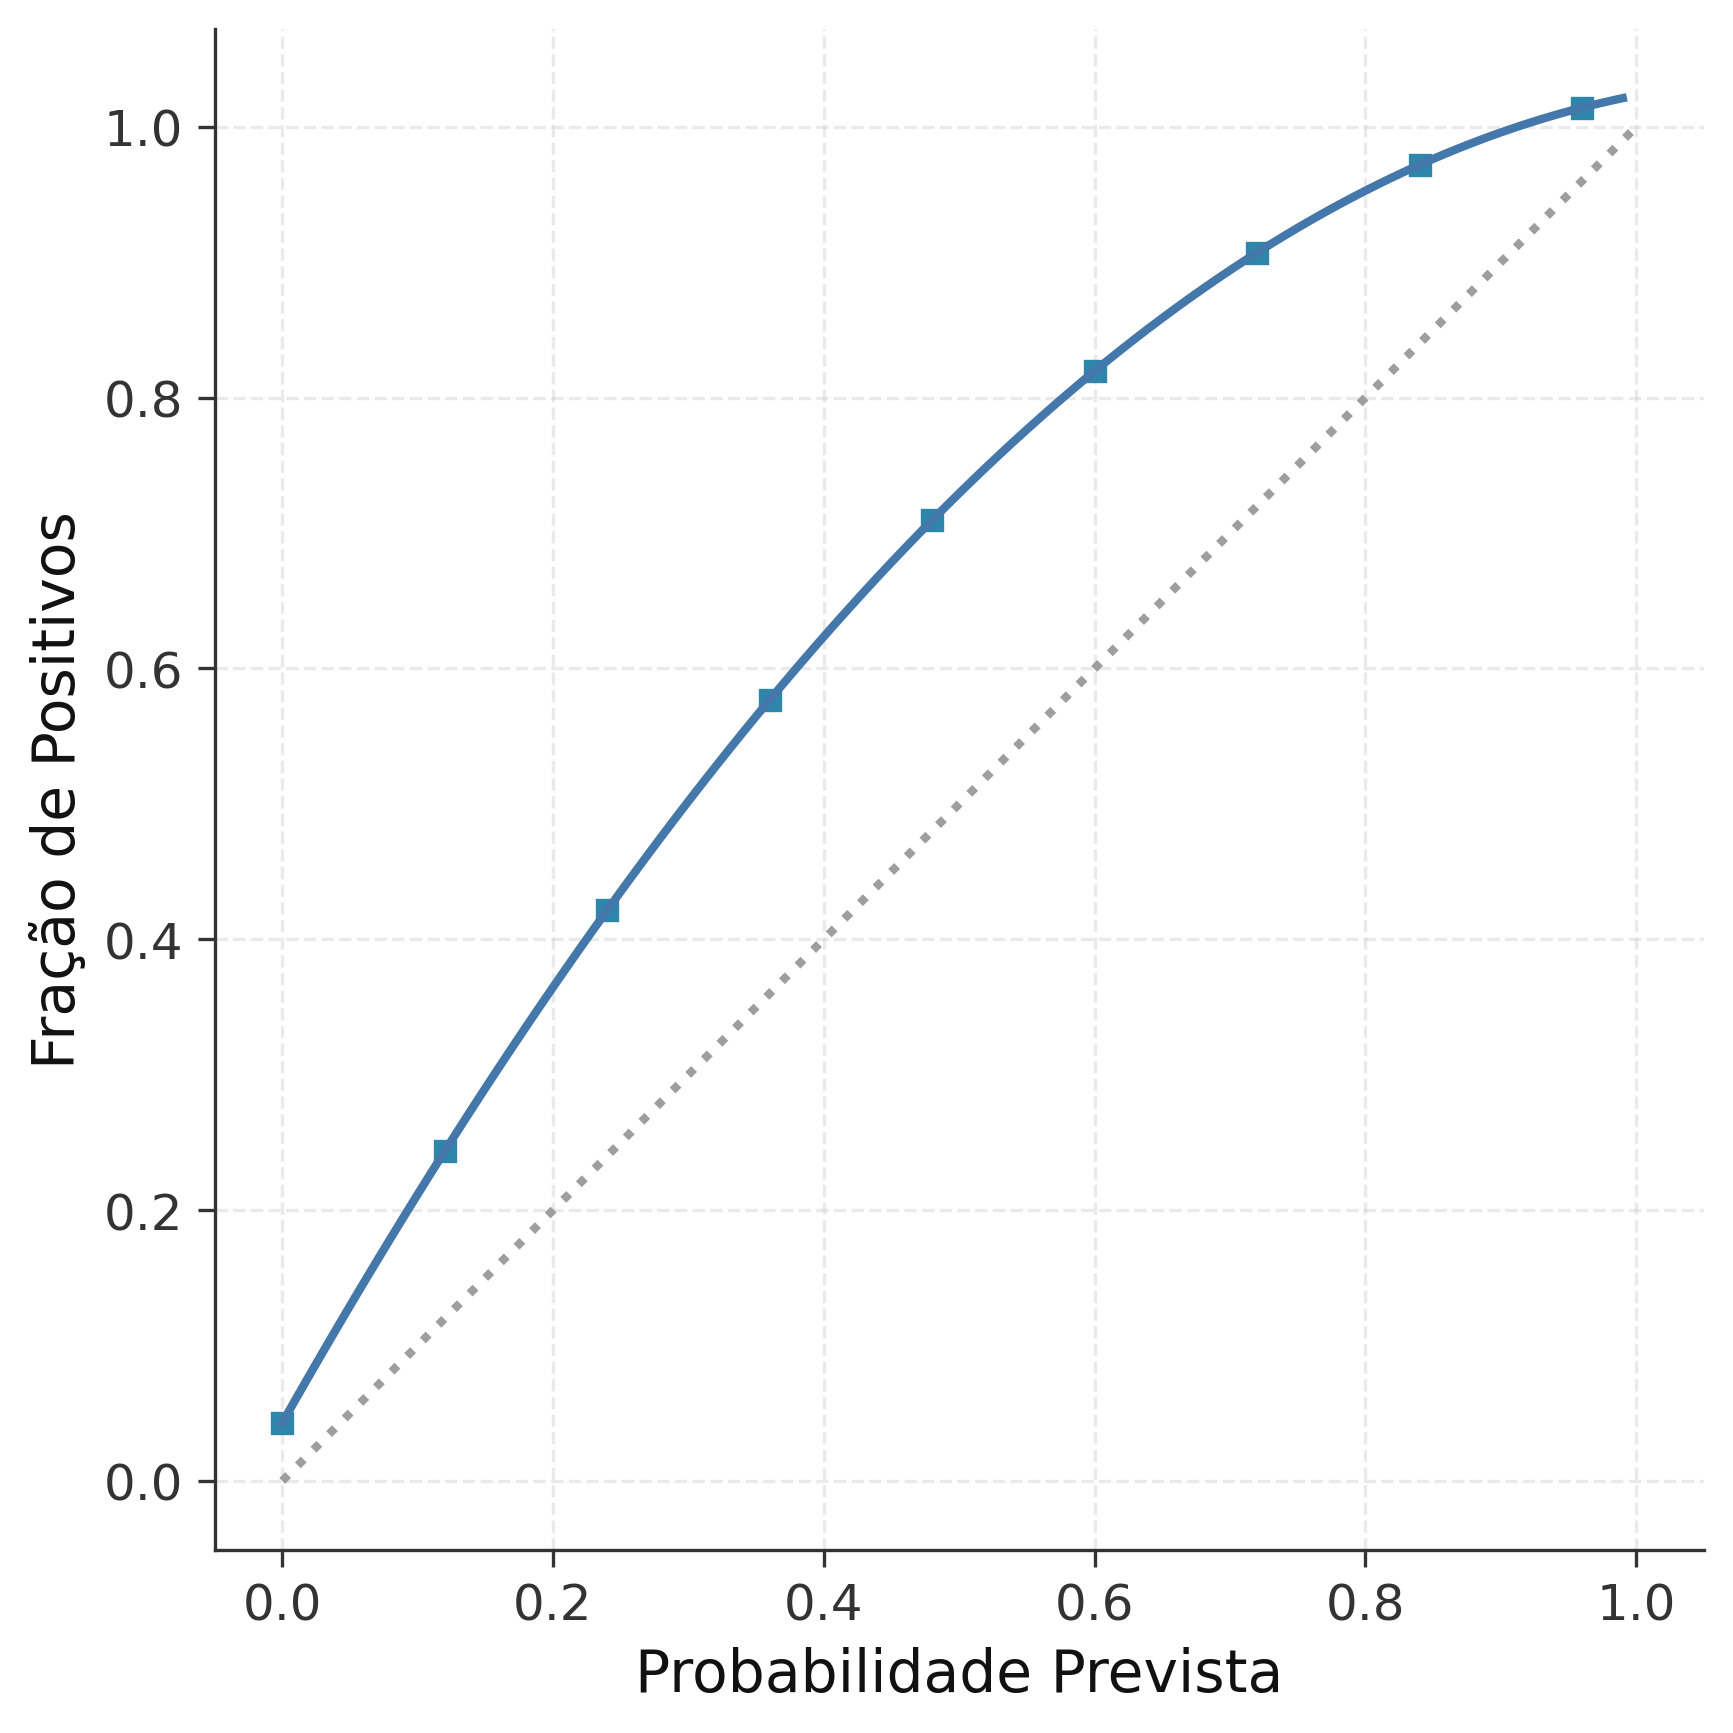

In [12]:
plt.figure(figsize=(6, 6))
plt.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), linestyle=":", color='#9E9E9E')
plt.plot(x_points, y_points, 's', color='#2E86AB')
plt.plot(x,y)

plt.xlabel('Probabilidade Prevista')
plt.ylabel('Fração de Positivos')
plt.savefig('undercofidence_example.pdf', dpi=300, bbox_inches='tight')

### Excesso de confiança

In [13]:
A = 0.4
B = 0.4
C = 0

In [14]:
from scipy.special import xlogy

In [15]:
x = np.arange(0,1,0.01)
y = 1 / (1 + np.exp(xlogy(-A, x) + xlogy(B, (1 - x)) - C))
x_points = np.arange(0,1,0.12)
y_points = 1 / (1 + np.exp(xlogy(-A, x_points) + xlogy(B, (1 - x_points)) - C))


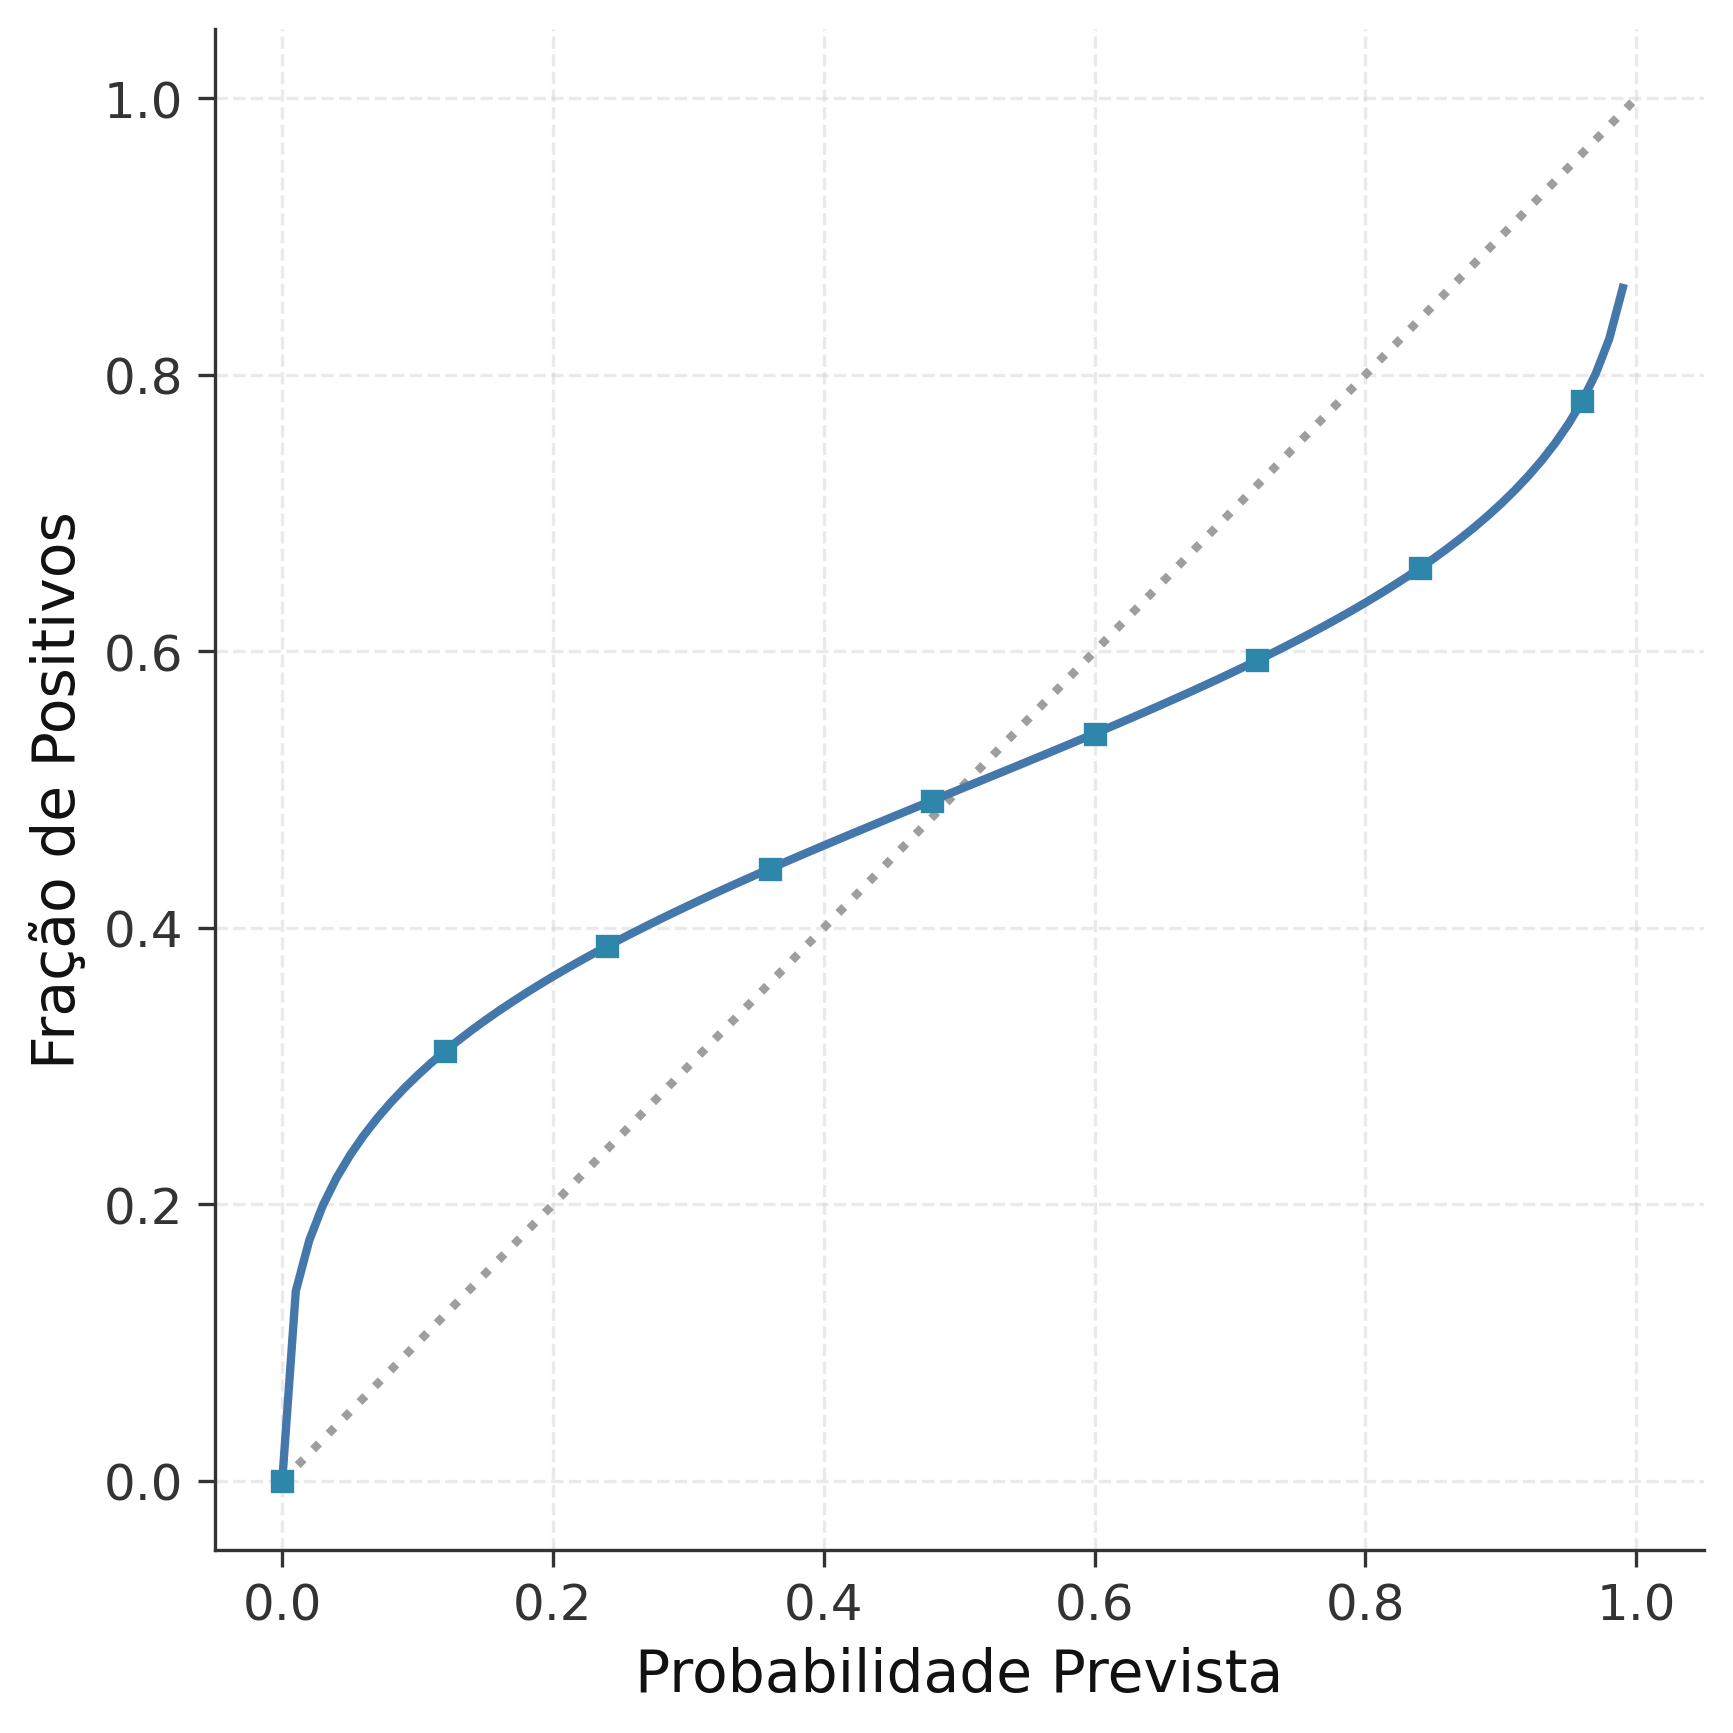

In [16]:
plt.figure(figsize=(6, 6))
plt.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), linestyle=":", color='#9e9e9e')
plt.plot(x,y)
plt.plot(x_points, y_points, 's', color='#2E86AB')

plt.xlabel('Probabilidade Prevista')
plt.ylabel('Fração de Positivos')
plt.savefig('overconfidence_example.pdf', dpi=300, bbox_inches='tight')


In [17]:
x = np.arange(0,1,0.01)
y = 0.7856*np.power(x,2) + 0.2342*x + 0.0019

x_points = np.arange(0,1,0.12)
y_points = 0.7856*np.power(x_points,2) + 0.2342*x_points + 0.0019

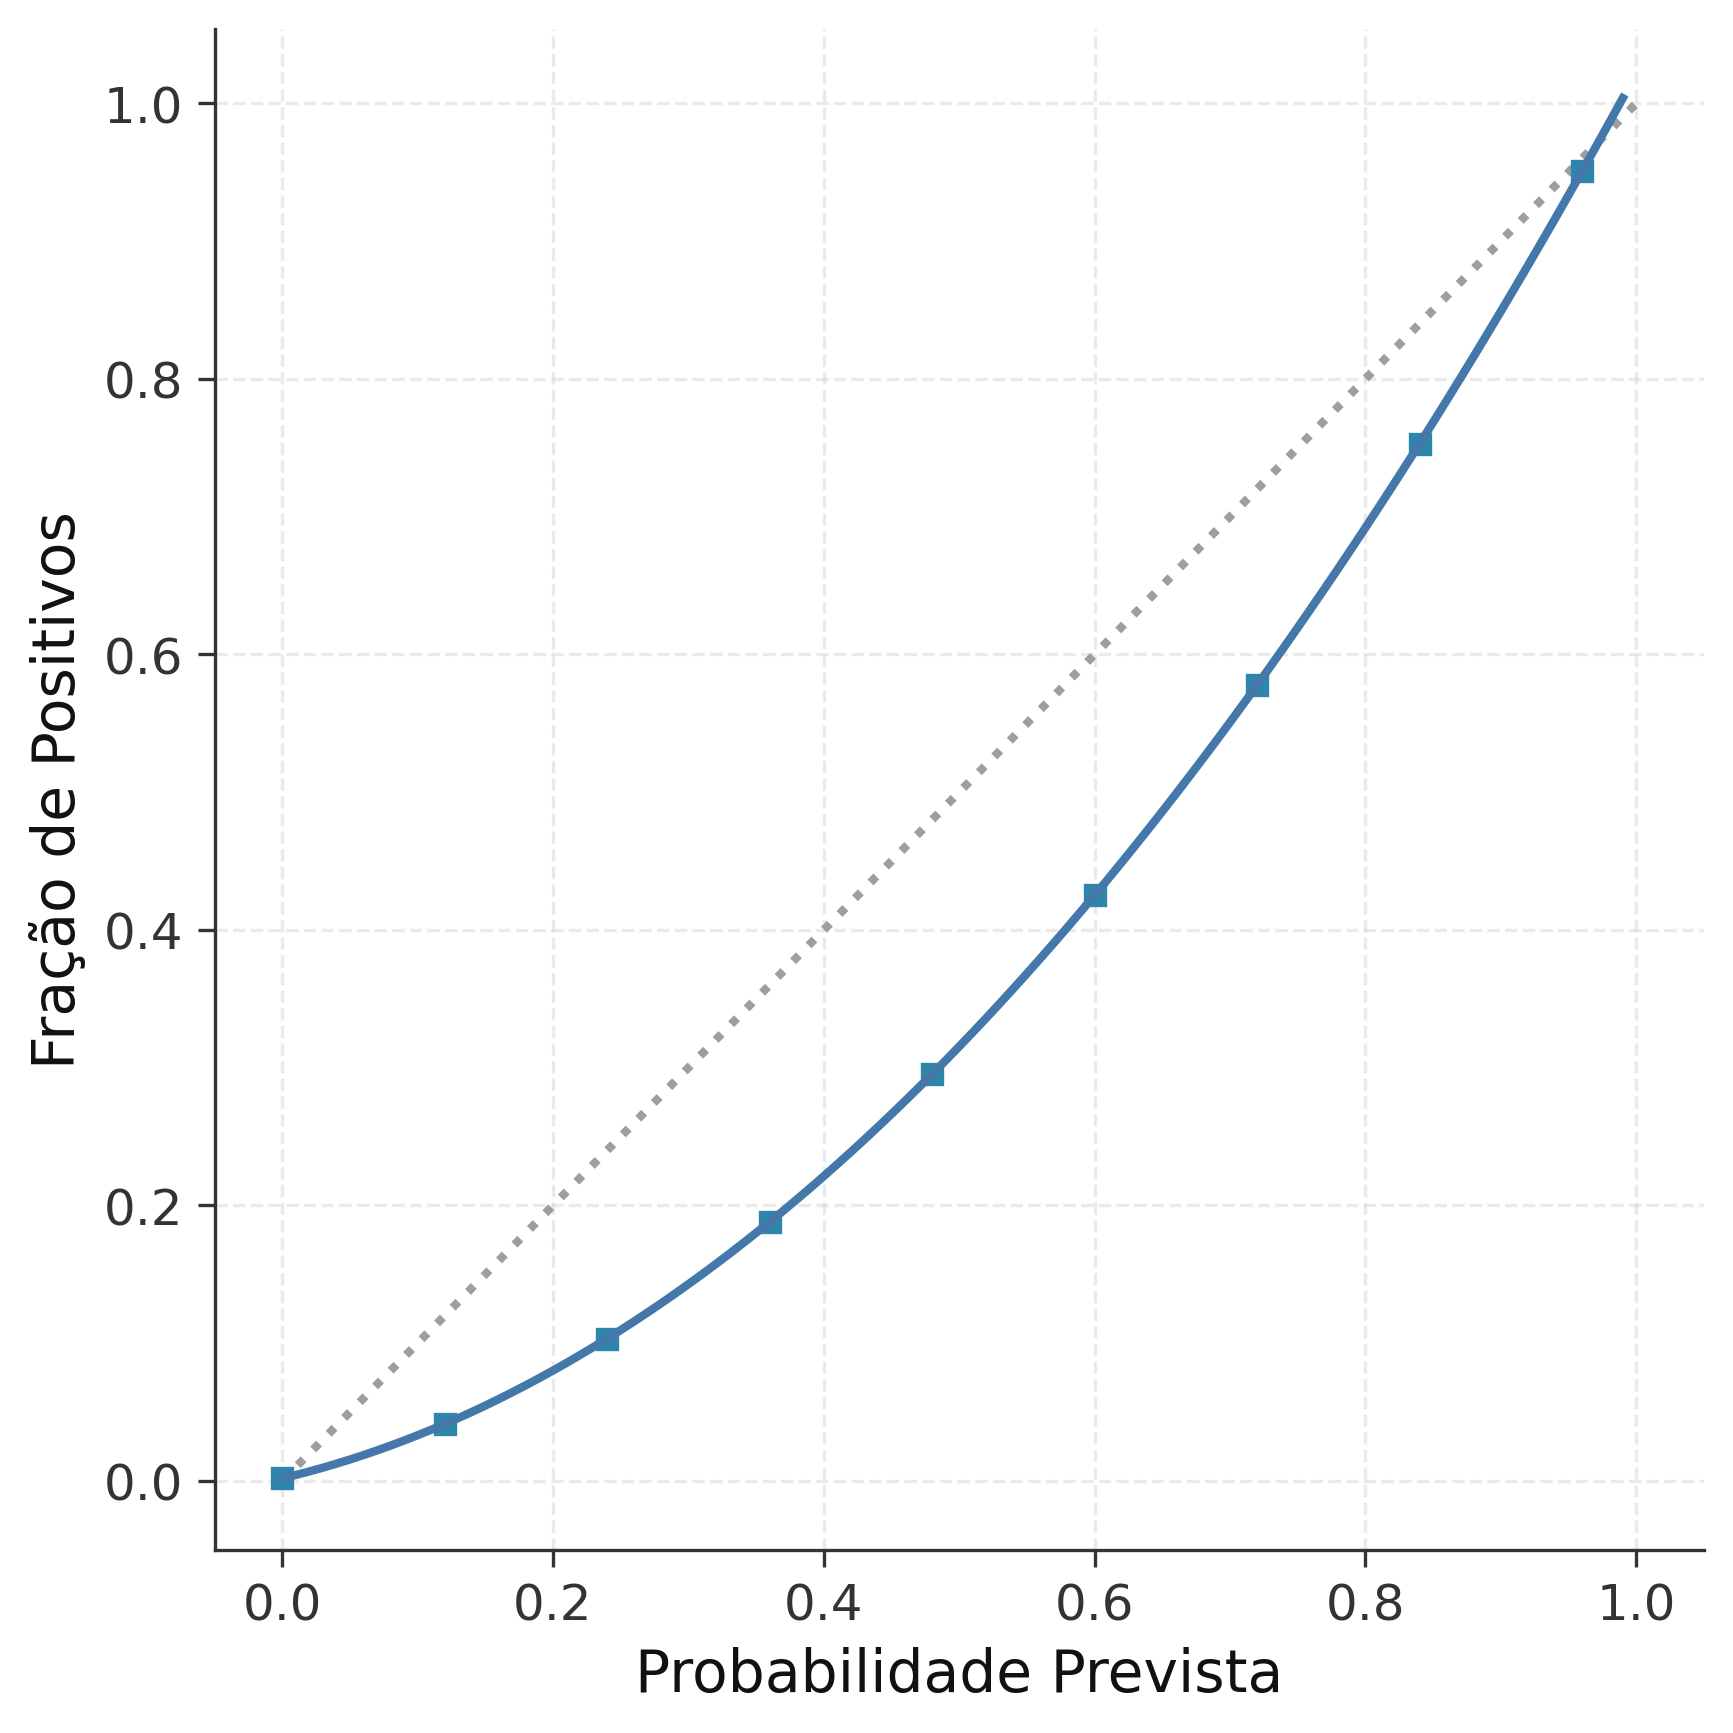

In [18]:
plt.figure(figsize=(6, 6))
plt.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), linestyle=":", color='#9e9e9e')
plt.plot(x_points, y_points, 's', color='#2E86AB')
plt.plot(x,y)

plt.xlabel('Probabilidade Prevista')
plt.ylabel('Fração de Positivos')
plt.savefig('overconfidence_example.pdf', dpi=300, bbox_inches='tight')

### Equal and same samples bins

In [19]:
x = np.random.rand(50)

In [20]:
n_bins = 10

In [21]:
bins = np.linspace(0.0, 1.0, n_bins + 1)
binids = np.searchsorted(bins[1:-1], x)

bin_total = np.bincount(binids, minlength=len(bins))

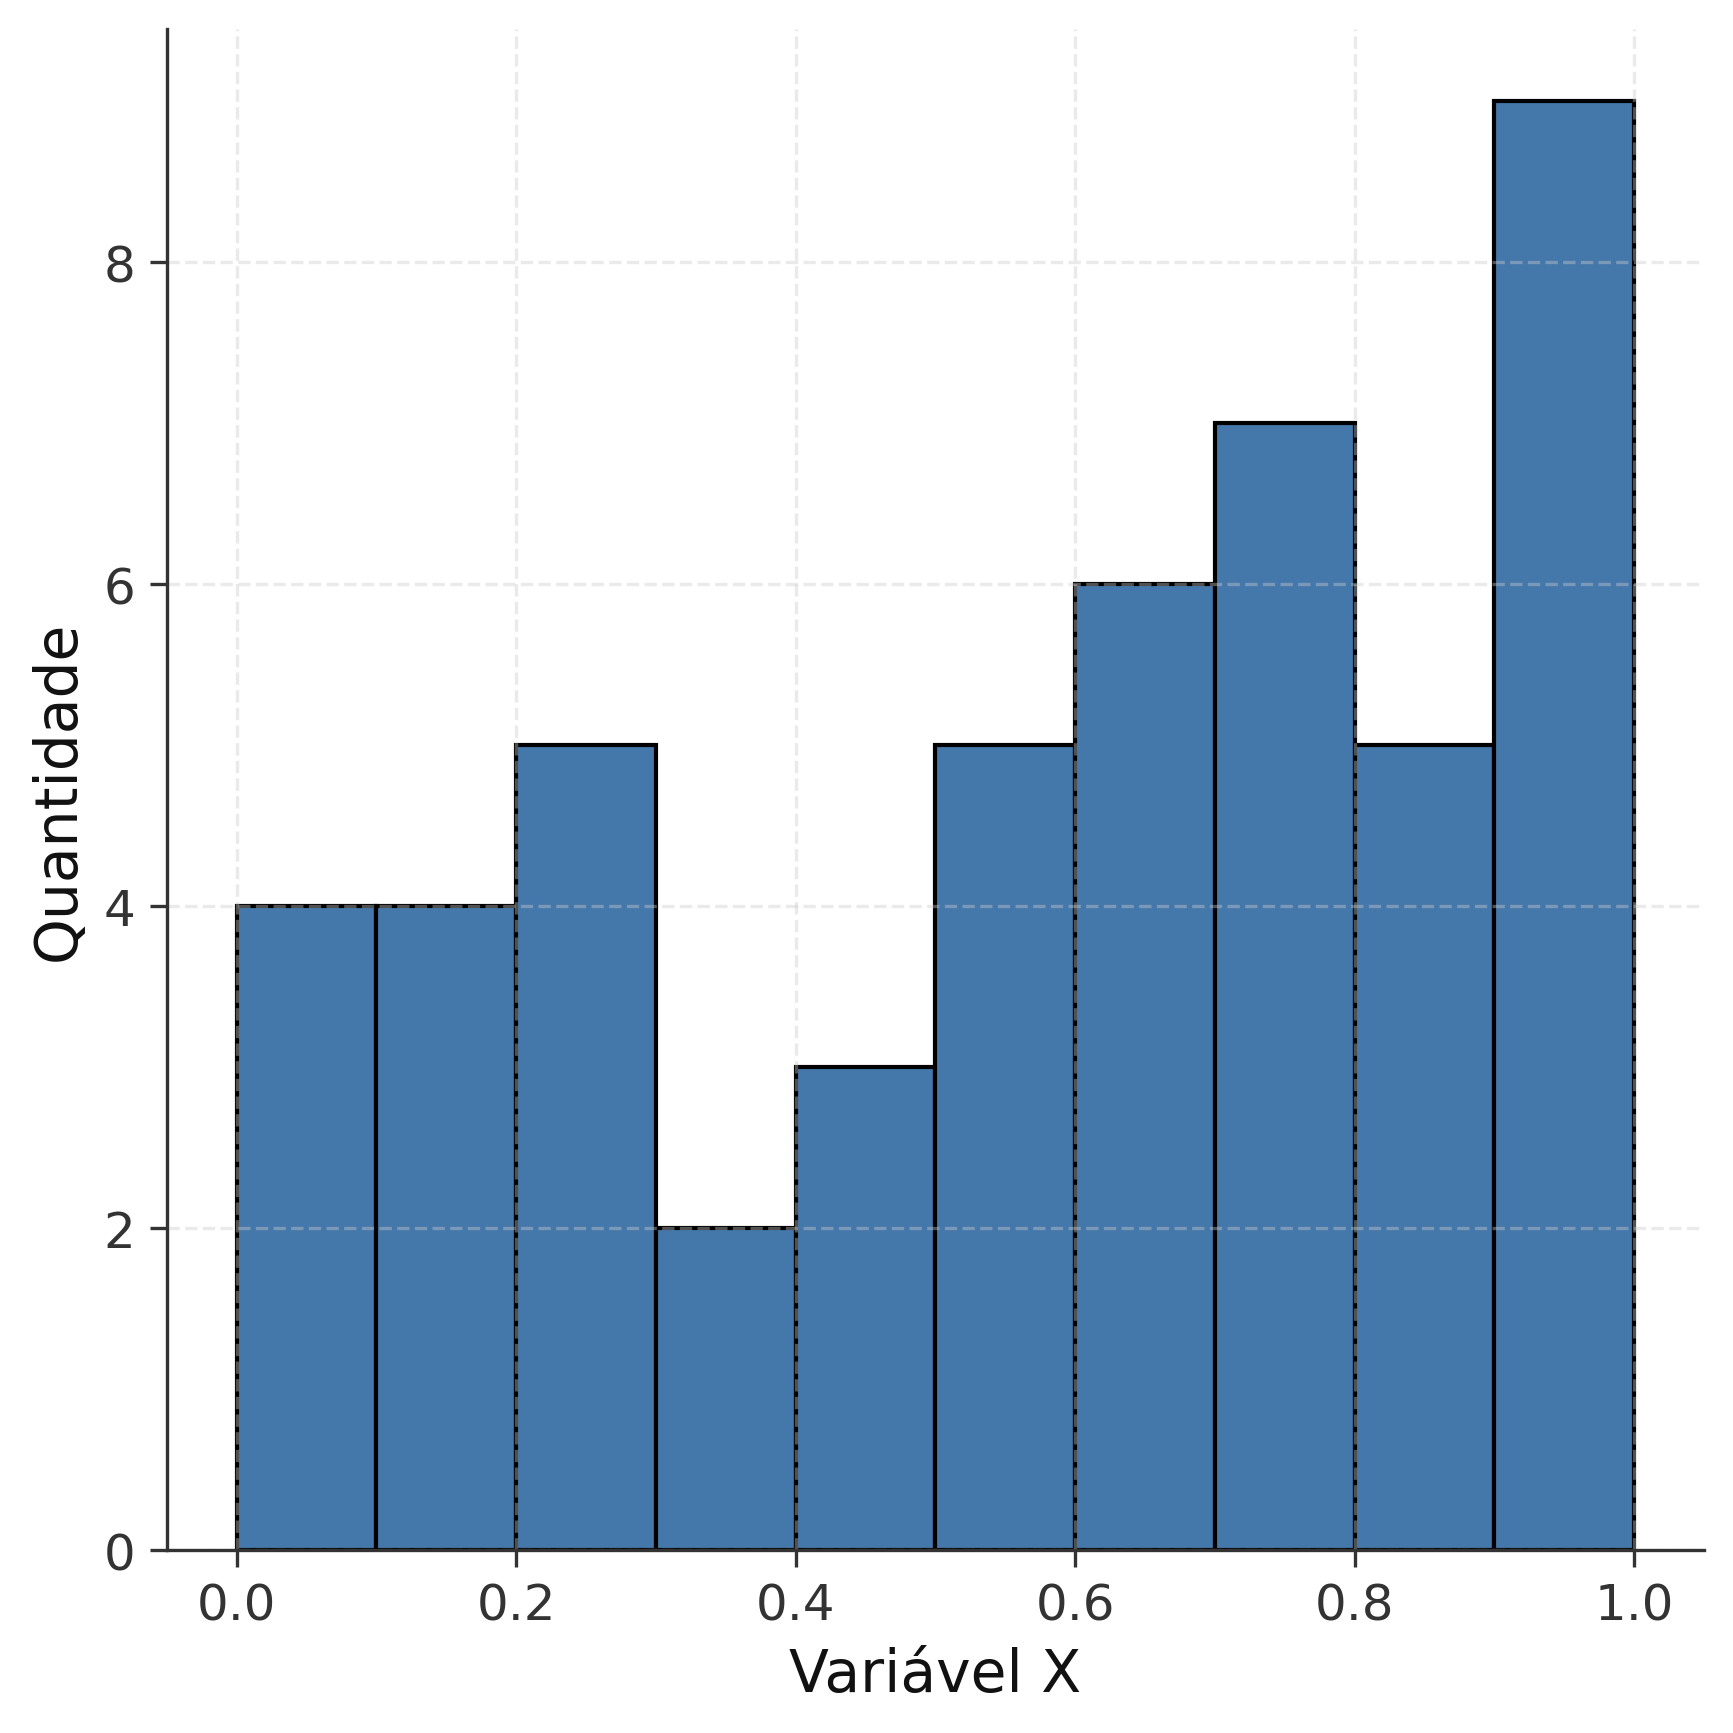

In [22]:
plt.figure(figsize=(6, 6))
plt.hist(x, bins=bins,edgecolor='k')
plt.xlabel('Variável X')
plt.ylabel('Quantidade')
plt.savefig('equal_width_bin_example.pdf', dpi=300, bbox_inches='tight')

In [23]:
quantiles = np.linspace(0, 1, n_bins + 1)
bins = np.percentile(x, quantiles * 100)

binids = np.searchsorted(bins[1:-1], x)
bin_total = np.bincount(binids, minlength=len(bins))

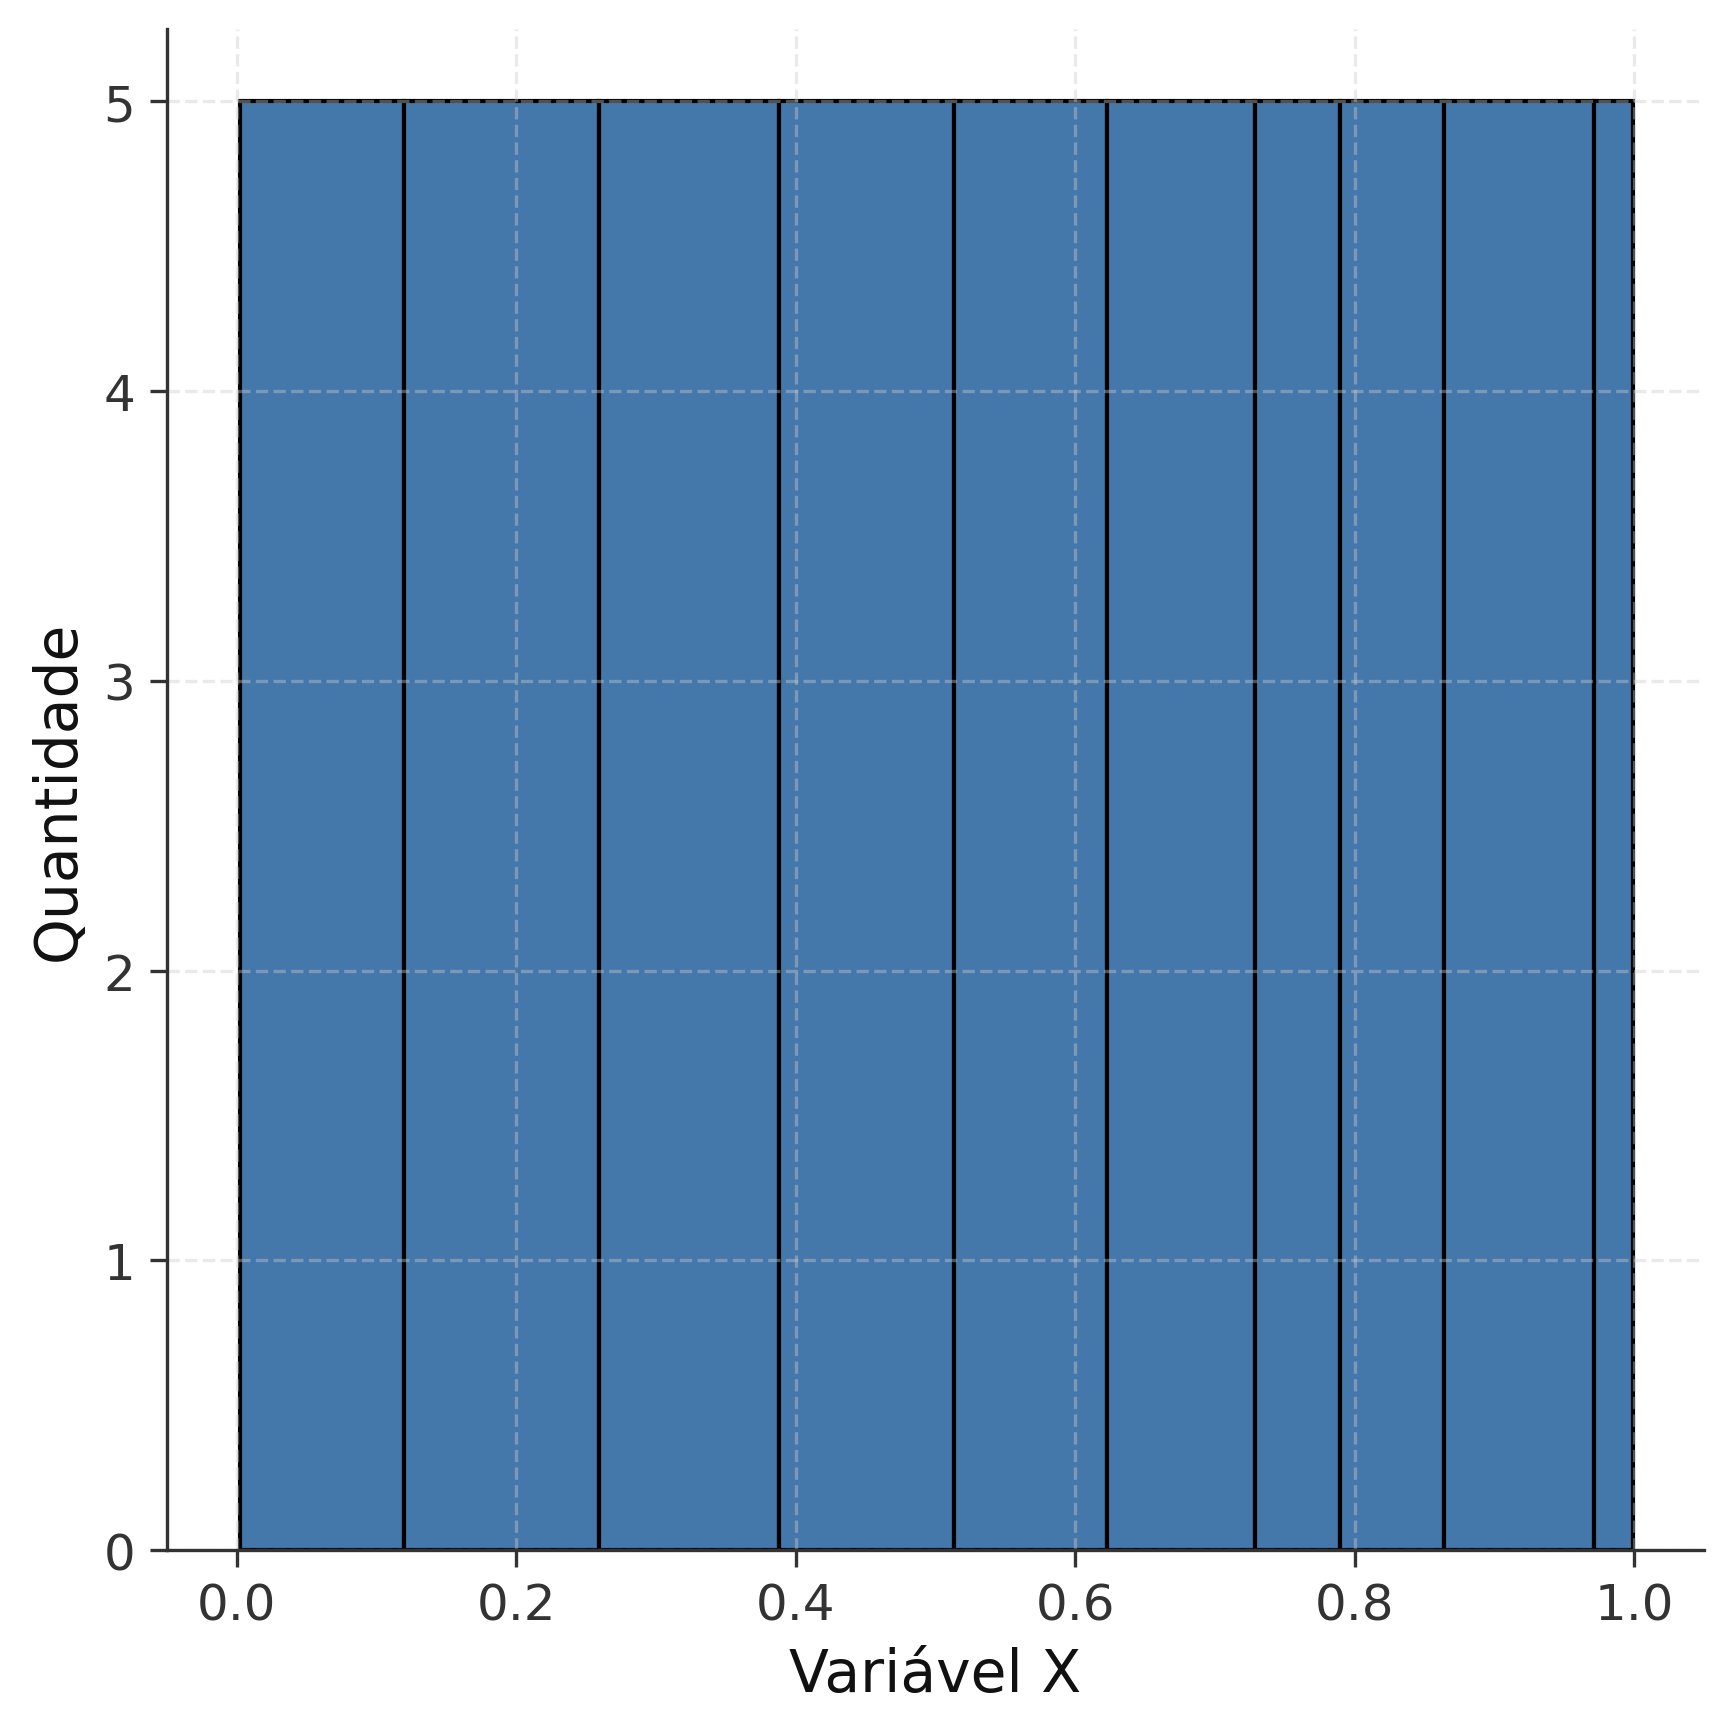

In [24]:
plt.figure(figsize=(6, 6))

plt.hist(x, bins=bins, edgecolor='k')
plt.xlabel('Variável X')
plt.ylabel('Quantidade')
plt.xlim([-0.05, 1.05])
plt.savefig('equal_samples_bin_example.pdf', dpi=300, bbox_inches='tight')

# Cross Entroyp Soft label

In [25]:
labels = [0.0,	0.3,	0.5,	0.7,  1.0]
probs = np.linspace(0.005,0.995, 100)

In [ ]:
from calibration.metrics import negative_log_likelihood

In [ ]:
plt.figure(figsize=(12, 6))

for label in labels:
    nll = []
    for prob in probs:
        nll.append(negative_log_likelihood(prob, label))
    plt.plot(probs, nll, label=f"Soft-Label = {str(label)}")

plt.legend()
plt.xlabel("Probabilidade Prevista")
plt.ylabel("Erro")
plt.xlim([-0.05, 1.05])
plt.savefig('erro_soft_labels.pdf', dpi=300, bbox_inches='tight')


In [ ]:
nll

# NFCS as sfot label

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
NFCS = np.array([0, 1, 2, 3, 4, 5])

linear =  np.array([0.005 , 0.2, 0.4, 0.6, 0.8, 1. ])


step = np.array([0.005, 0.005, 0.3, 0.7, 1, 1])

sigmoid = 1 / (1 + np.exp(-NFCS+2.5))

hard = np.array([0.005, 0.005, 0.005, 1, 1, 1])

: 

In [ ]:
width = 0.3      
plt.figure(figsize=(10,5))

# Plotting
plt.bar(NFCS, linear , width, label='Linear')
plt.bar(NFCS + width, step, width, label='Intervalo')
plt.bar(NFCS + width * 2 , sigmoid, width, label='Sigmoid')
#plt.bar(NFCS + width * 3, hard, width, label='Hard-Label')

plt.xlabel('NFCS')
plt.ylabel('Soft-Label')

# xticks()
# First argument - A list of positions at which ticks should be placed
# Second argument -  A list of labels to place at the given locations
plt.xticks(NFCS + width*1, ('0', '1', '2', '3', '4', '5'))

# Finding the best position for legends and putting it
plt.legend(loc='best')
plt.savefig('soft_labels_example.png', dpi=300, bbox_inches='tight')

# MCDP Example

In [26]:
x = np.hstack((np.random.randint(0,300,40)/1000, np.random.randint(300,600,20)/1000, np.random.randint(600,1001,40)/1000))

In [27]:
x_mean = x.mean()
x_std = x.std()

In [28]:
n_bins = 10
bins = np.linspace(0.0, 1.0, n_bins + 1)
binids = np.searchsorted(bins[1:-1], x)

bin_total = np.bincount(binids, minlength=len(bins))

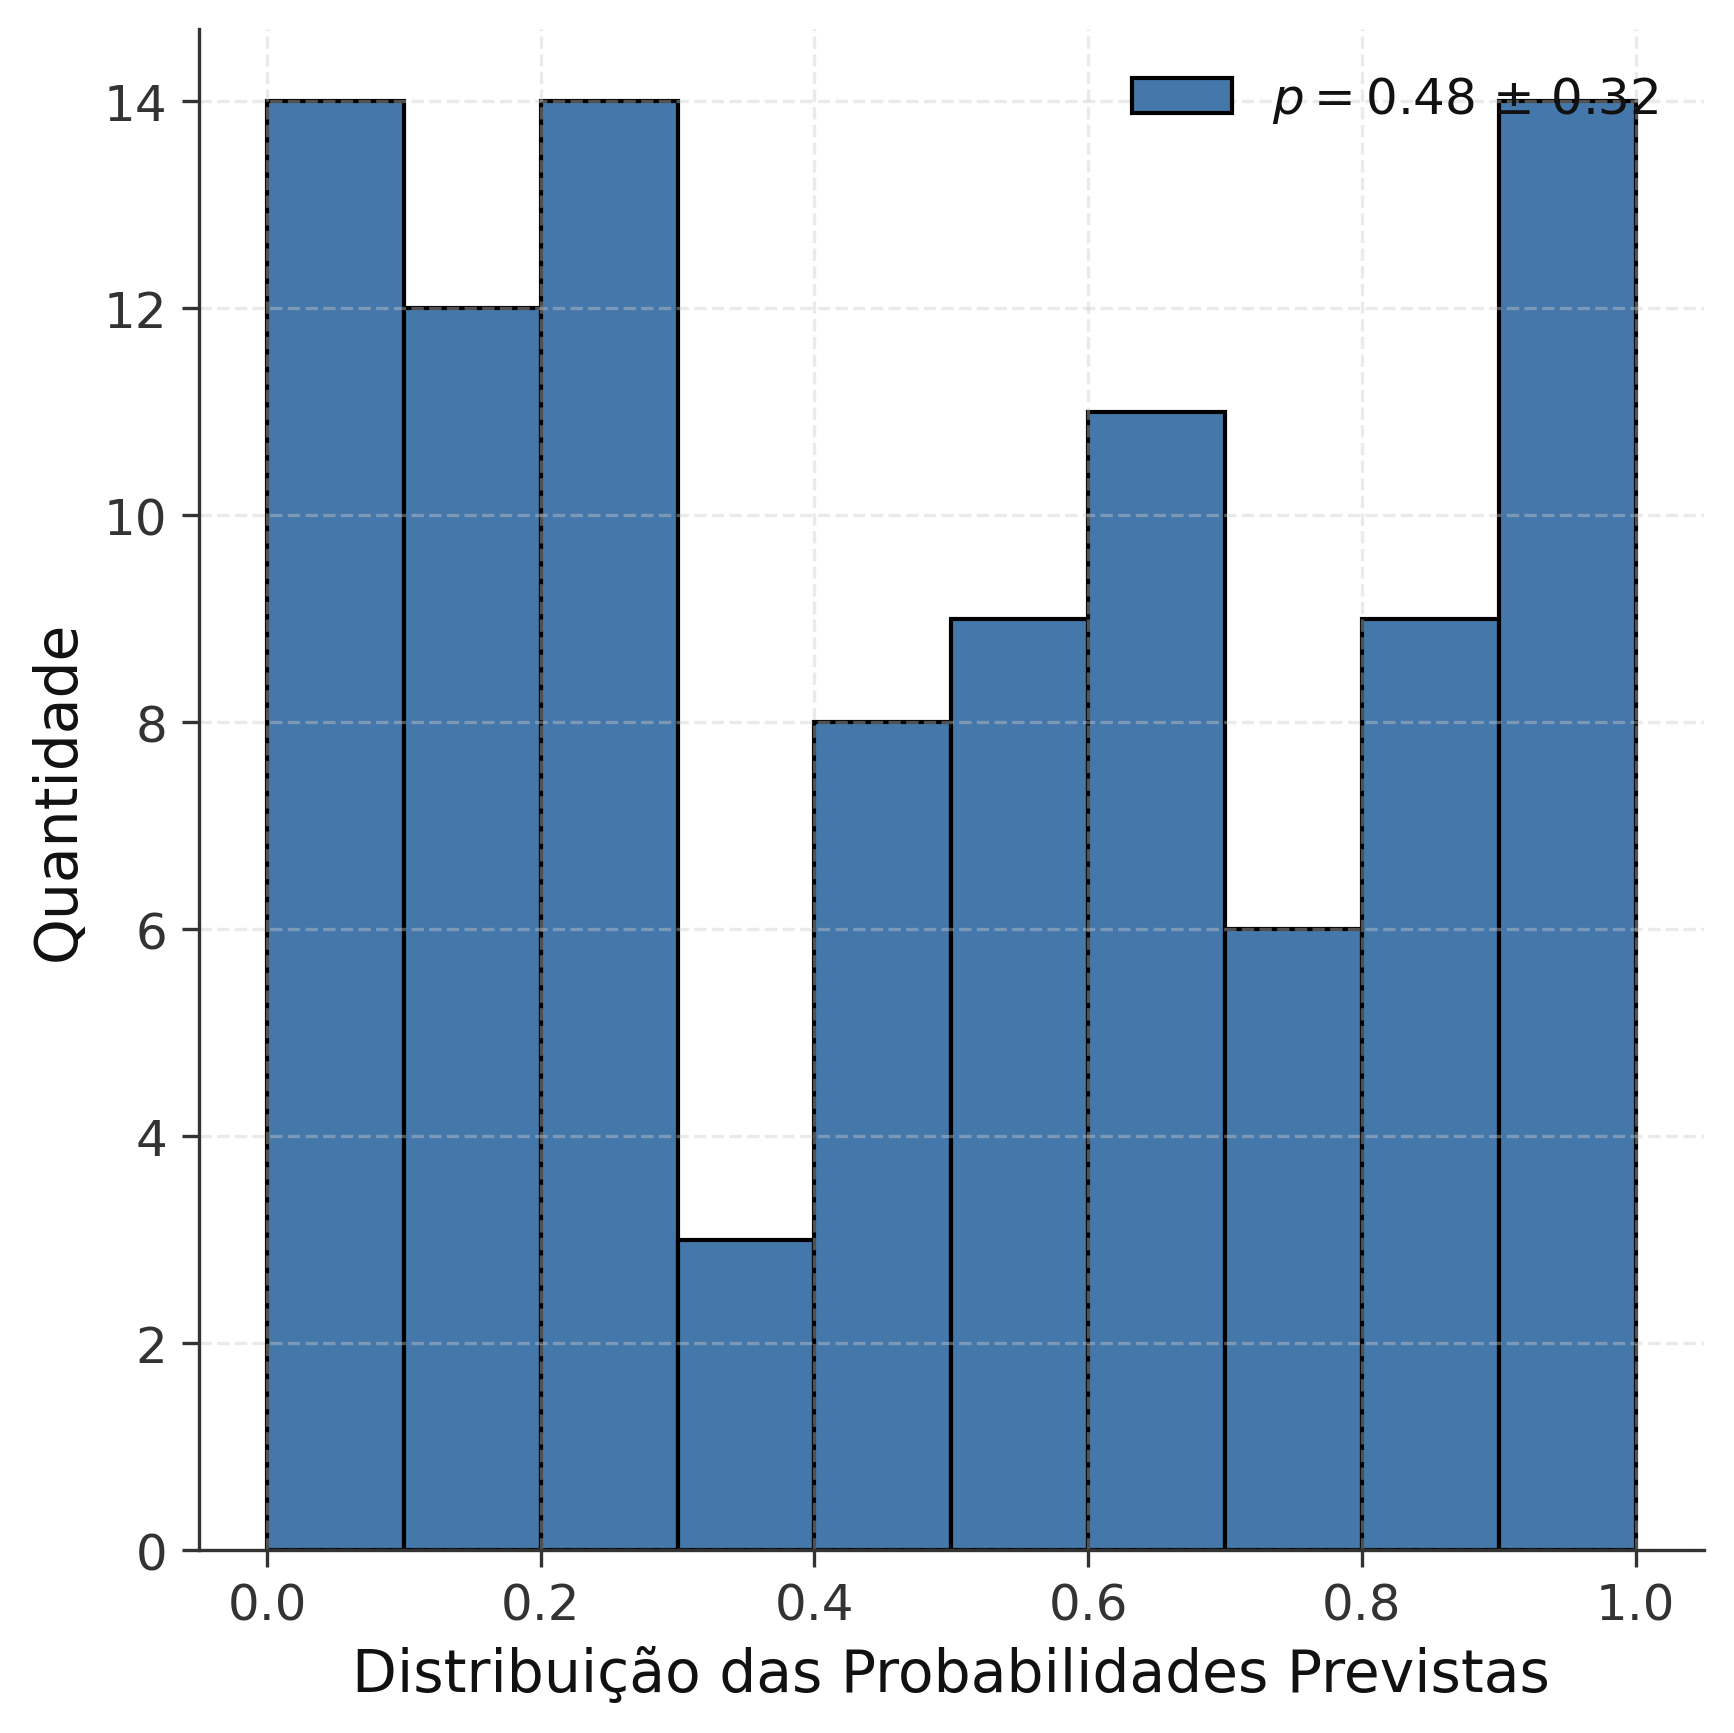

In [29]:
plt.figure(figsize=(6, 6))
plt.hist(x, bins=bins,edgecolor='k', label=f'$p = {x_mean:.2f}$ ± ${x_std:.2f}$')
plt.xlabel('Distribuição das Probabilidades Previstas')
plt.ylabel('Quantidade')
plt.legend()
plt.savefig('MCDP_uncertainty_example.pdf', dpi=300, bbox_inches='tight')

In [30]:
x = np.hstack((np.random.randint(400,600,80)/1000))

x_mean = x.mean()
x_std = x.std()

n_bins = 10
bins = np.linspace(0.0, 1.0, n_bins + 1)
binids = np.searchsorted(bins[1:-1], x)
bin_total = np.bincount(binids, minlength=len(bins))

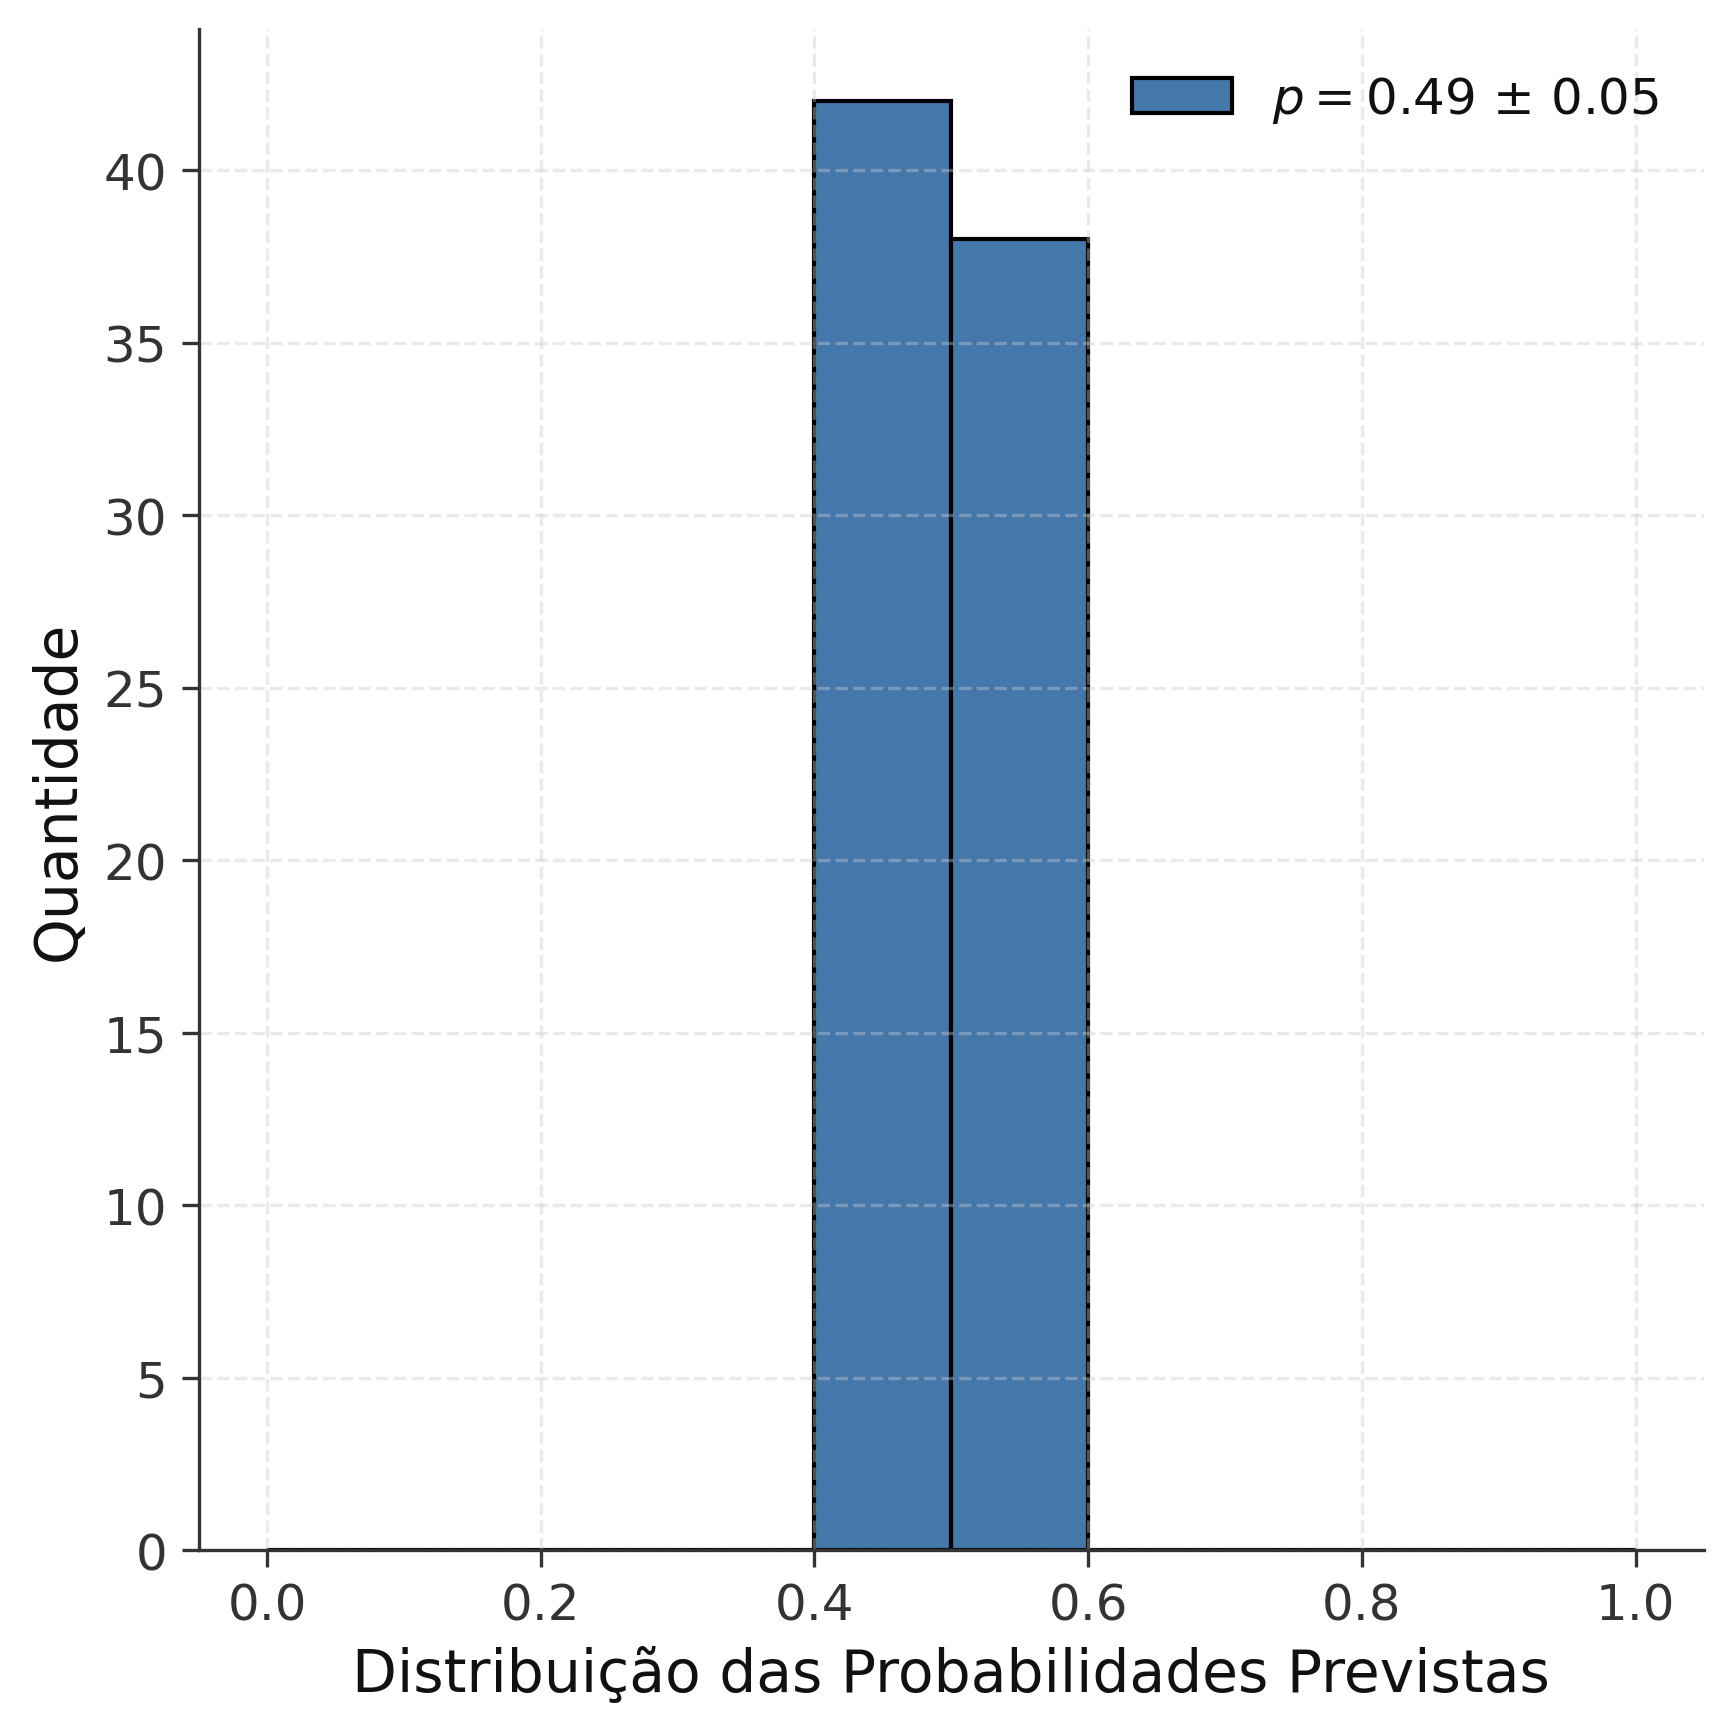

In [31]:
plt.figure(figsize=(6, 6))
plt.hist(x, bins=bins,edgecolor='k', label=f'$p = {x_mean:.2f}$ ± ${x_std:.2f}$')
plt.xlabel('Distribuição das Probabilidades Previstas')
plt.ylabel('Quantidade')
plt.legend()
plt.savefig('MCDP_certainty_example.pdf', dpi=300, bbox_inches='tight')

# Face detection example

In [ ]:
import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pickle
from XAI.metrics import *
import os

In [ ]:
img_path = "Datasets\\NewDataset\\Images\\ID106_iCOPE_S10_nopain.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)


bbox = [597, 1025, 1368, 1884]
img = cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color=(255,0,0), thickness=15)

In [ ]:
plt.imshow(img)
plt.axis('off')
plt.savefig('face_detected.png', dpi=300, bbox_inches='tight')

In [ ]:
img_path = "Datasets\\Folds\\3\\Test\\ID106_iCOPE_S10_nopain.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

with open('Datasets\\DatasetFaces\\Landmarks\\ID106_iCOPE_S10_nopain.pkl', 'rb') as f:
    face_mesh = np.array(pickle.load(f))

In [ ]:
plt.imshow(img)
for x,y in face_mesh:
    plt.plot(x,y,'ro')

plt.axis('off')
plt.savefig('face_mesh.png', dpi=300, bbox_inches='tight')

In [ ]:
plt.imshow(img)
for x,y in face_mesh[[86,52,61,88,38]]:
    plt.plot(x,y,'ro')

plt.axis('off')
plt.savefig('face_landmarks.png', dpi=300, bbox_inches='tight')

# Corruption Examples


In [ ]:
import cv2
import corruption
import matplotlib.pyplot as plt
import numpy as np
import pickle
from XAI.metrics import *

In [ ]:
img_path = "Datasets\\Folds\\2\\Test\\ID644_iCOPE_S58_pain.jpg"
img = cv2.imread(img_path)
#img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

with open('Datasets\\landmarks\\ID644_iCOPE_S58_pain.pkl', 'rb') as f:
    face_mesh = np.array(pickle.load(f))

In [ ]:
plt.imshow(img)

In [ ]:
corruptions = {"brightness": np.arange(0.1, 2.2, 0.2), "downscale": np.arange(0.05, 1, 0.1), 
               "blur": np.arange(1, 45, 4), "rotation": np.arange(-90,100,20),
               "translate_x": np.arange(-0.5, 0.6, 0.1), "translate_y": np.arange(-0.5, 0.6, 0.1),
               "face": ["eyebrown", "eye","nose", "between_eyes","mouth","chin","nasolabial_fold", "cheek","forehead"]}

In [ ]:
for tipo, factors in corruptions.items():

    if "translate" in tipo:
        corruption_function = getattr(corruption, "translate")
    elif "face" in tipo:
        corruption_function = getattr(corruption, "region_patches")
    else:
        corruption_function = getattr(corruption, tipo)    

    img_stack = []
    for factor in factors:

        if "translate_x" in tipo:
            corrup_img = corruption_function(img, factor, axis="x")  
        elif "translate_y" in tipo:
            corrup_img = corruption_function(img, factor, axis="y")
        elif "face" in tipo:
            region_masks = create_face_regions_masks(face_mesh) 

            if factor == "eye" or factor == "eyebrown" or factor == "nasolabial_fold" or factor == "cheek":
                factors = [f'left_{factor}', f'right_{factor}']
                corrup_img = corruption_function(img, [region_masks[region] for region in factors]) 

            else:
                corrup_img = corruption_function(img, [region_masks[region] for region in [factor]]) 

        else:
            corrup_img = corruption_function(img, factor)

        img_stack.append(corrup_img)
        stacked = np.hstack(img_stack)

        cv2.imwrite(f"corruption_{tipo}.png", stacked)

    

    
                            

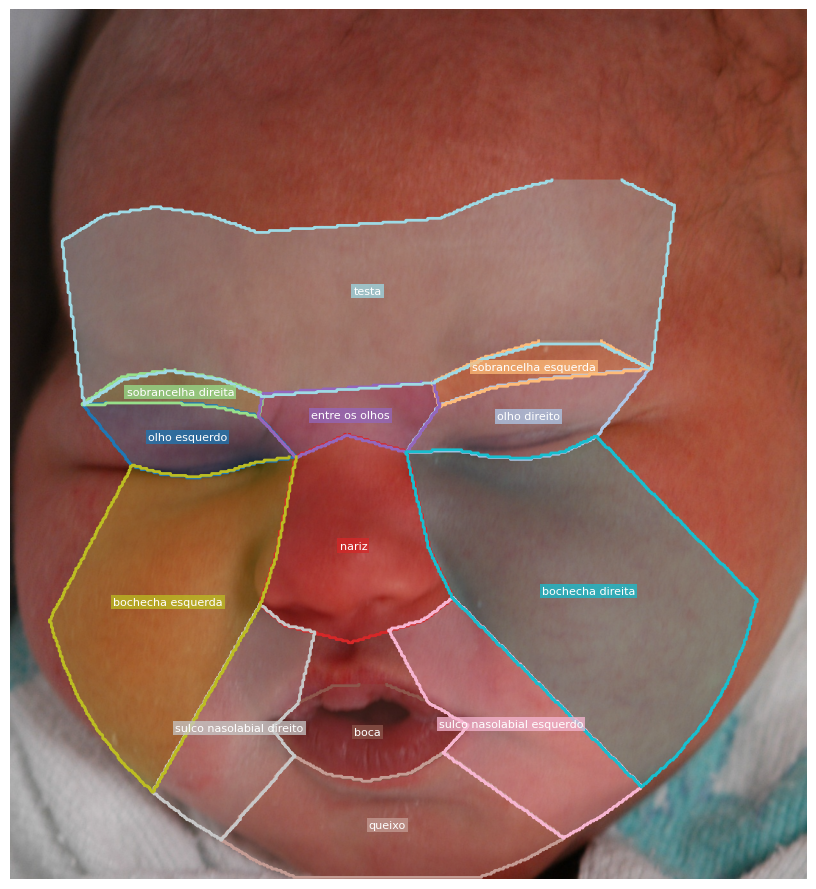

In [4]:
from pathlib import Path
import pickle

import cv2
import matplotlib.pyplot as plt
import numpy as np
from XAI.metrics import create_face_regions_masks


images_dir = Path("Datasets") / "DatasetFaces" / "Images"
landmarks_dir = Path("Datasets") / "DatasetFaces" / "Landmarks"
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

if not images_dir.is_dir():
    raise FileNotFoundError(f"Cropped face image directory not found: {images_dir}")
if not landmarks_dir.is_dir():
    raise FileNotFoundError(f"Keypoints directory not found: {landmarks_dir}")

matched_pairs = [
    (image_path, landmarks_dir / f"{image_path.stem}.pkl")
    for image_path in sorted(images_dir.iterdir())
    if image_path.suffix.lower() in image_extensions
    and (landmarks_dir / f"{image_path.stem}.pkl").is_file()
]

if not matched_pairs:
    raise FileNotFoundError(
        f"No cropped face images with matching keypoint .pkl files found in "
        f"{images_dir} and {landmarks_dir}."
    )

# Pick any available example. Change the index to inspect another face.
image_path, keypoints_path = matched_pairs[0]

image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise ValueError(f"Could not read image: {image_path}")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

with keypoints_path.open("rb") as handle:
    keypoints = np.asarray(pickle.load(handle), dtype=np.float32)

if keypoints.ndim != 2 or keypoints.shape[1] != 2:
    raise ValueError(f"Unexpected keypoints shape in {keypoints_path}: {keypoints.shape}")

region_masks = create_face_regions_masks(keypoints)
region_labels = {
    "left_eye": "olho esquerdo",
    "right_eye": "olho direito",
    "left_eyebrown": "sobrancelha esquerda",
    "right_eyebrown": "sobrancelha direita",
    "nose": "nariz",
    "between_eyes": "entre os olhos",
    "mouth": "boca",
    "chin": "queixo",
    "left_nasolabial_fold": "sulco nasolabial esquerdo",
    "right_nasolabial_fold": "sulco nasolabial direito",
    "left_cheek": "bochecha esquerda",
    "right_cheek": "bochecha direita",
    "forehead": "testa",
}
colors = plt.cm.tab20(np.linspace(0, 1, len(region_labels)))

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(image_rgb)

image_height, image_width = image_rgb.shape[:2]
for color, (region_name, label) in zip(colors, region_labels.items()):
    mask = region_masks.get(region_name)
    if mask is None:
        continue

    resized_mask = cv2.resize(
        mask.astype(np.uint8),
        (image_width, image_height),
        interpolation=cv2.INTER_NEAREST,
    )
    overlay = np.zeros((image_height, image_width, 4), dtype=np.float32)
    overlay[..., :3] = color[:3]
    overlay[..., 3] = (resized_mask > 0) * 0.28
    ax.imshow(overlay)

    contours, _ = cv2.findContours(resized_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        contour = contour.squeeze(axis=1)
        ax.plot(contour[:, 0], contour[:, 1], color=color[:3], linewidth=2)

    ys, xs = np.where(resized_mask > 0)
    if len(xs) and len(ys):
        ax.text(
            xs.mean(),
            ys.mean(),
            label,
            color="white",
            fontsize=8,
            ha="center",
            va="center",
            bbox={"facecolor": color[:3], "alpha": 0.75, "edgecolor": "none", "pad": 1.5},
        )

ax.axis("off")
plt.tight_layout()
plt.show()


,Modelo,Região,Importância
0,NCNN,nariz,0.873486
1,NCNN,boca,0.634123
2,NCNN,olhos,0.625180
3,NCNN,entre os olhos,0.507085
4,NCNN,sobrancelhas,0.383981
10,VGGFace,boca,0.730924
11,VGGFace,olhos,0.250045
12,VGGFace,sulcos nasolabiais,0.246551
13,VGGFace,bochechas,0.232953
14,VGGFace,queixo,0.115260


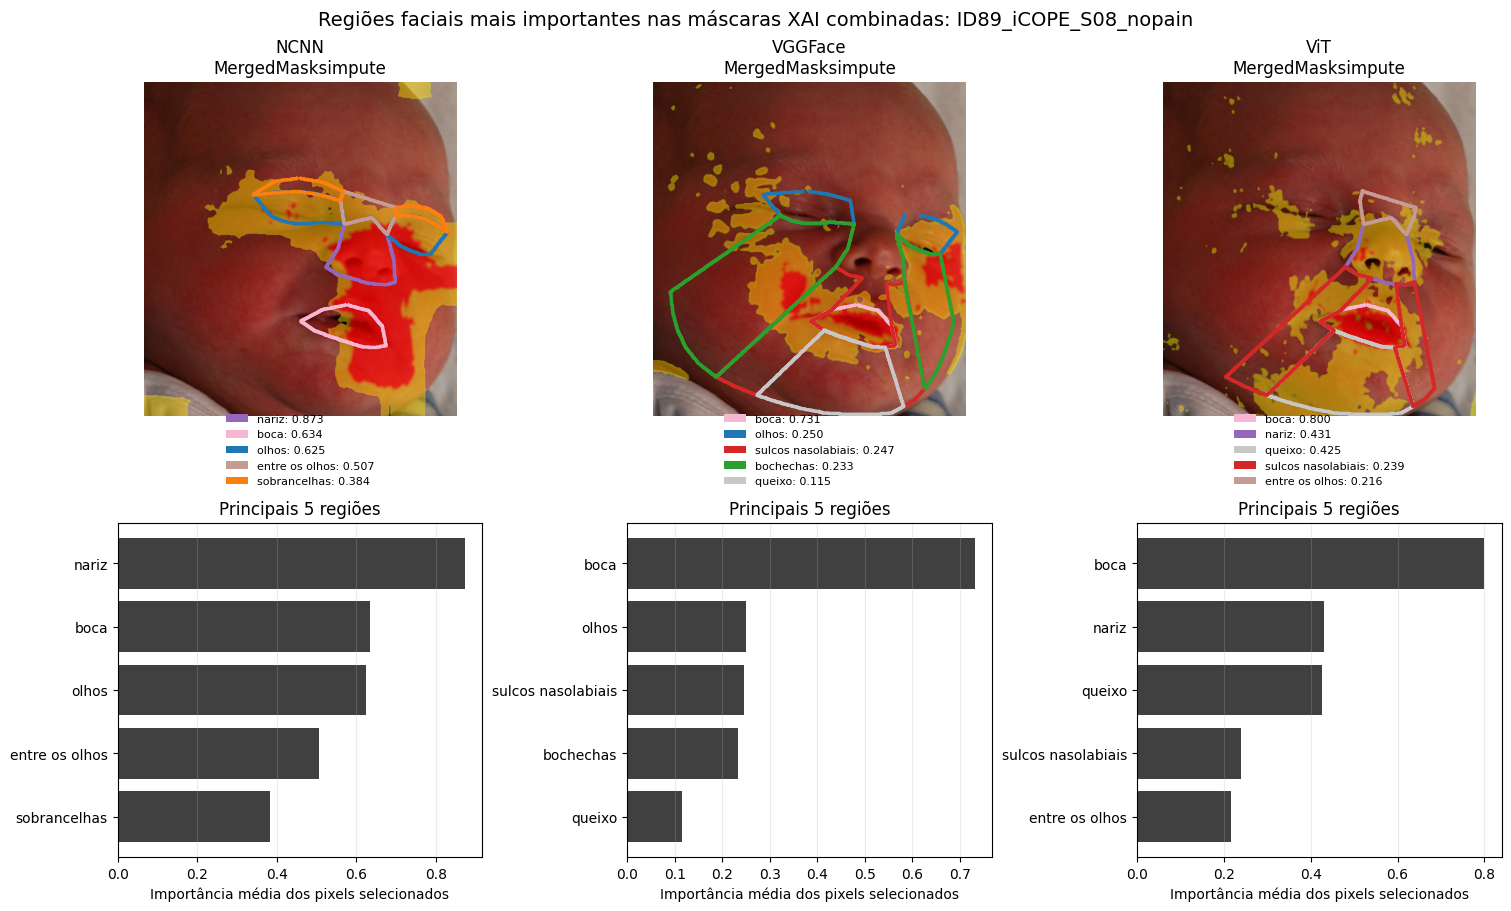

In [8]:
from pathlib import Path
import pickle

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

from XAI import kmeans_post_processing
from XAI.metrics import calculate_xai_score, create_face_regions_masks


image_id = "ID89_iCOPE_S08_nopain"
merge_strategy = "MergedMasksimpute"  # outra opção: "MergedMasksaveragebaseline"
kmeans_alpha_thres = 0.5
top_regions_to_draw = 5
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["green", "yellow", "red"])

image_path = Path("Datasets") / "DatasetFaces" / "Images" / f"{image_id}.jpg"
keypoints_path = Path("Datasets") / "DatasetFaces" / "Landmarks" / f"{image_id}.pkl"
merged_masks_dir = Path("RGU") / "XAI_EXPLAINERS" / "MERGED_MASKS"
model_dirs = {
    "NCNN": "NCNN",
    "VGGFace": "VGGFace",
    "ViT": "ViT_B_32",
}
region_labels = {
    "eyes": "olhos",
    "eyebrows": "sobrancelhas",
    "cheeks": "bochechas",
    "nasolabial folds": "sulcos nasolabiais",
    "nose": "nariz",
    "between_eyes": "entre os olhos",
    "mouth": "boca",
    "chin": "queixo",
    "forehead": "testa",
    "outside": "fora do rosto",
}

missing = [path for path in [image_path, keypoints_path, merged_masks_dir] if not path.exists()]
if missing:
    raise FileNotFoundError("Entrada(s) obrigatória(s) ausente(s):\n" + "\n".join(str(path) for path in missing))

image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise ValueError(f"Não foi possível ler a imagem: {image_path}")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_height, image_width = image_rgb.shape[:2]

with keypoints_path.open("rb") as handle:
    keypoints = np.asarray(pickle.load(handle), dtype=np.float32)

def merge_symmetric_regions(face_masks: dict) -> dict:
    merge_map = {
        ("left_eye", "right_eye"): "eyes",
        ("left_eyebrown", "right_eyebrown"): "eyebrows",
        ("left_cheek", "right_cheek"): "cheeks",
        ("left_nasolabial_fold", "right_nasolabial_fold"): "nasolabial folds",
    }
    merged_masks = {}
    merged_keys = set()

    for (left_region, right_region), merged_name in merge_map.items():
        if left_region in face_masks and right_region in face_masks:
            merged_masks[merged_name] = np.logical_or(
                face_masks[left_region] > 0,
                face_masks[right_region] > 0,
            ).astype(np.float32)
            merged_keys.update([left_region, right_region])

    for region, mask in face_masks.items():
        if region not in merged_keys:
            merged_masks[region] = mask

    return merged_masks


region_masks = merge_symmetric_regions(create_face_regions_masks(keypoints))
region_colors = dict(zip(region_masks, plt.cm.tab20(np.linspace(0, 1, len(region_masks)))))


def load_npz_mask(mask_path: Path) -> np.ndarray:
    with np.load(mask_path) as data:
        key = "mask" if "mask" in data.files else data.files[0]
        mask = np.asarray(data[key], dtype=np.float32)

    mask = np.squeeze(mask)
    if mask.ndim == 3:
        mask = mask.mean(axis=-1)

    if mask.max() > 1.0:
        mask = mask / 255.0

    mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_LINEAR)
    mask_min, mask_max = float(mask.min()), float(mask.max())
    if mask_max > mask_min:
        mask = (mask - mask_min) / (mask_max - mask_min)

    return mask


records = []
model_results = {}

for model_name, model_dir in model_dirs.items():
    mask_path = merged_masks_dir / model_dir / merge_strategy / f"{image_id}.npz"
    if not mask_path.is_file():
        raise FileNotFoundError(f"Máscara XAI combinada não encontrada para {model_name}: {mask_path}")

    xai_mask = load_npz_mask(mask_path)
    processed_mask, alpha_channel = kmeans_post_processing(
        xai_mask,
        n_clusters=5,
        ksize=11,
        sigma=0,
        alpha_thres=kmeans_alpha_thres,
        use_mini_batch=True,
    )
    important_pixels = processed_mask * alpha_channel
    region_scores = calculate_xai_score(important_pixels, region_masks, sort=True)
    top_regions = list(region_scores.items())[:top_regions_to_draw]

    model_results[model_name] = {
        "path": mask_path,
        "mask": xai_mask,
        "processed_mask": processed_mask,
        "alpha_channel": alpha_channel,
        "important_pixels": important_pixels,
        "scores": region_scores,
        "top_regions": top_regions,
    }

    for region, score in region_scores.items():
        records.append({"Modelo": model_name, "Região": region_labels.get(region, region), "Importância": score})

score_df = pd.DataFrame(records)
display(score_df.groupby("Modelo", sort=False).head(top_regions_to_draw))

fig, axes = plt.subplots(2, len(model_results), figsize=(5 * len(model_results), 9), constrained_layout=True)

for col, (model_name, result) in enumerate(model_results.items()):
    ax = axes[0, col]
    processed_overlay = cv2.resize(result["processed_mask"], (image_width, image_height))
    alpha_mask = cv2.resize(
        result["alpha_channel"].astype(np.float32),
        (image_width, image_height),
        interpolation=cv2.INTER_NEAREST,
    )
    alpha_overlay = alpha_mask * (0.20 + 0.45 * np.clip(processed_overlay, 0.0, 1.0))

    ax.imshow(image_rgb)
    ax.imshow(processed_overlay, cmap=cmap, alpha=alpha_overlay)

    legend_handles = []
    for region, score in result["top_regions"]:
        region_mask = cv2.resize(
            region_masks[region].astype(np.uint8),
            (image_width, image_height),
            interpolation=cv2.INTER_NEAREST,
        )
        color = region_colors[region]
        contours, _ = cv2.findContours(region_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            contour = contour.squeeze(axis=1)
            if contour.ndim == 2:
                ax.plot(contour[:, 0], contour[:, 1], color=color[:3], linewidth=2.5)
        legend_handles.append(Patch(facecolor=color[:3], label=f"{region_labels.get(region, region)}: {score:.3f}"))

    ax.set_title(f"{model_name}\n{merge_strategy}")
    ax.axis("off")
    ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.24), fontsize=8, frameon=False)

    top_df = pd.DataFrame(result["top_regions"], columns=["Region", "Score"])
    top_df["Region"] = top_df["Region"].map(lambda region: region_labels.get(region, region))

    bar_ax = axes[1, col]
    bar_ax.barh(top_df["Region"][::-1], top_df["Score"][::-1], color="0.25")
    bar_ax.set_xlabel("Importância média dos pixels selecionados")
    bar_ax.set_title(f"Principais {top_regions_to_draw} regiões")
    bar_ax.grid(axis="x", alpha=0.25)

fig.suptitle(f"Regiões faciais mais importantes nas máscaras XAI combinadas: {image_id}", fontsize=14)
plt.show()


Figura salva em: outputs\xai_region_importance\ID89_iCOPE_S08_nopain_NCNN_MergedMasksimpute_regioes_importancia.png


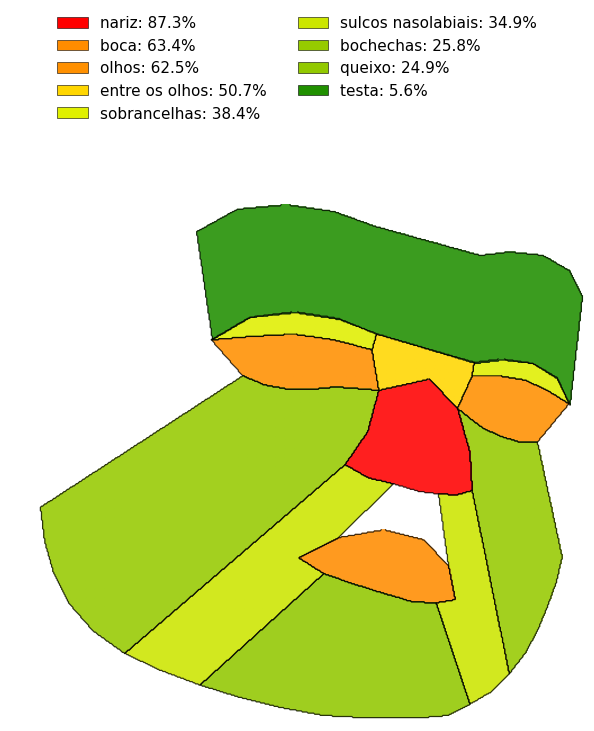

Figura salva em: outputs\xai_region_importance\ID89_iCOPE_S08_nopain_VGGFace_MergedMasksimpute_regioes_importancia.png


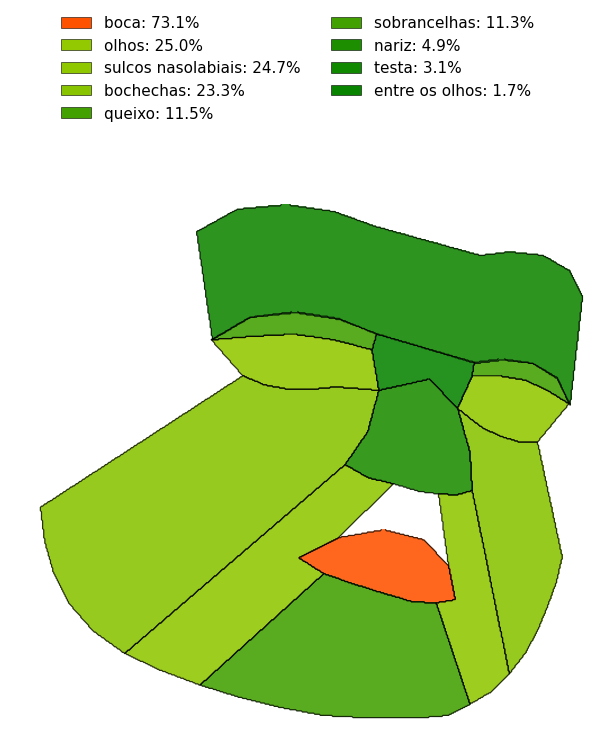

Figura salva em: outputs\xai_region_importance\ID89_iCOPE_S08_nopain_ViT_MergedMasksimpute_regioes_importancia.png


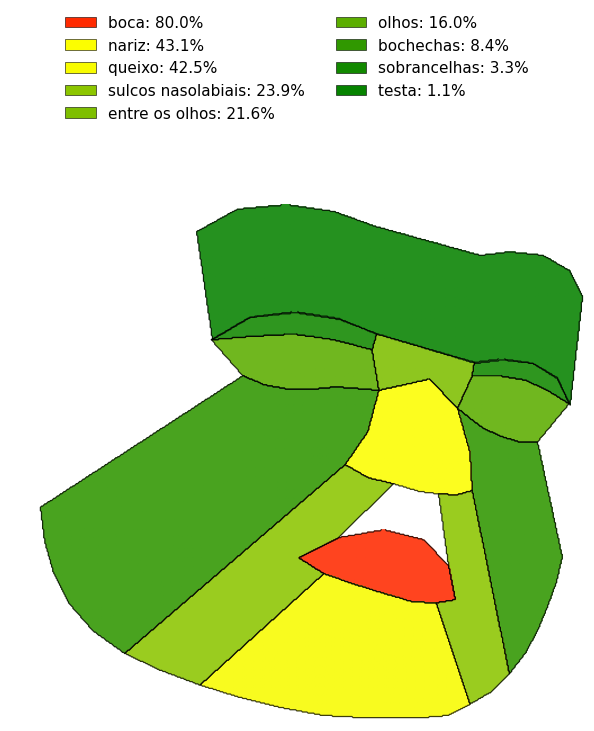

In [9]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


required_vars = ["model_results", "region_masks", "region_labels", "cmap", "image_id"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Execute primeiro a célula de sobreposição XAI combinada. Variáveis ausentes: " + ", ".join(missing_vars)
    )

regions_to_plot = [region for region in region_masks if region != "outside"]
all_region_scores = [
    result["scores"].get(region, 0.0)
    for result in model_results.values()
    for region in regions_to_plot
]
score_norm = matplotlib.colors.Normalize(vmin=0.0, vmax=max(all_region_scores) if all_region_scores else 1.0)
figure_output_dir = Path("outputs") / "xai_region_importance"
figure_output_dir.mkdir(parents=True, exist_ok=True)

for model_name, result in model_results.items():
    fig, ax = plt.subplots(figsize=(6.0, 7.2), constrained_layout=True)
    region_canvas = np.ones((512, 512, 4), dtype=np.float32)
    region_canvas[..., :3] = 1.0
    region_canvas[..., 3] = 0.0

    for region in regions_to_plot:
        region_mask = region_masks[region] > 0
        score = result["scores"].get(region, 0.0)
        color = cmap(score_norm(score))
        region_canvas[region_mask, :3] = color[:3]
        region_canvas[region_mask, 3] = 0.88

    ax.imshow(region_canvas)

    for region in regions_to_plot:
        region_mask = (region_masks[region] > 0).astype(np.uint8)
        contours, _ = cv2.findContours(region_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            contour = contour.squeeze(axis=1)
            if contour.ndim == 2:
                ax.plot(contour[:, 0], contour[:, 1], color="black", linewidth=0.9, alpha=0.75)

    ax.set_xlim(0, 511)
    ax.set_ylim(511, 0)
    ax.set_aspect("equal")
    ax.axis("off")

    legend_handles = []
    sorted_regions = sorted(regions_to_plot, key=lambda region: result["scores"].get(region, 0.0), reverse=True)
    for region in sorted_regions:
        score = result["scores"].get(region, 0.0)
        legend_handles.append(
            Patch(
                facecolor=cmap(score_norm(score))[:3],
                edgecolor="black",
                linewidth=0.4,
                label=f"{region_labels.get(region, region)}: {score * 100:.1f}%",
            )
        )
    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        fontsize=11,
        title_fontsize=12,
        frameon=False,
    )

    output_path = figure_output_dir / f"{image_id}_{model_name}_{merge_strategy}_regioes_importancia.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.05)
    print(f"Figura salva em: {output_path}")
    plt.show()
